# FinRL Stock Trading: PPO Intrinsic Reward Ablation

This experiment follows the structure and reporting protocol of
`FinRL_PortfolioOptimization_PPO_Synthetic_vs_Real` while comparing the
original StockTrading reward with Surprise, Déjà vu, and their combination.
All validation and backtest metrics use **external financial reward only**.
Intrinsic-reward quantities are reported in a separate diagnostic section.


## Experimental protocol

- Preserve FinRL's original all-cash, zero-share initial state.
- Check every semantic training-cache key before constructing PPO runs.
- Load all cache hits first; train only misses with outer and per-step tqdm bars.
- Compare sampled-policy reward, deterministic train/real-validation reward,
  generalization gap, validation behaviour, and PPO internals.
- Aggregate each reward variant across seeds as mean ± one standard deviation.
- Select a median-test-Sharpe representative for transparency while retaining
  all-seed aggregate backtests and portfolio weights.
- Treat equal-weight Buy & Hold as a deterministic benchmark, not a trained model.


In [1]:
from __future__ import annotations

import contextlib
import io
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image as NotebookImage
from tqdm.auto import tqdm


def _bootstrap_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "finrl").is_dir() and (candidate / "examples").is_dir():
            return candidate
    raise RuntimeError("Could not locate the FinRL project root")


PROJECT_ROOT = _bootstrap_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

with contextlib.redirect_stderr(io.StringIO()):
    from finrl.experiments.notebook_utils import check_calendar_coverage
    from finrl.experiments.notebook_utils import environment_flag
    from finrl.experiments.notebook_utils import read_real_ohlcv_csvs
    from finrl.experiments.stock_intrinsic import DEFAULT_TECH_INDICATORS
    from finrl.experiments.stock_intrinsic import VARIANT_WEIGHTS
    from finrl.experiments.stock_intrinsic import build_training_environment
    from finrl.experiments.stock_intrinsic import evaluate_experiment_periods
    from finrl.experiments.stock_intrinsic import plan_variant_training
    from finrl.experiments.stock_intrinsic import plot_intrinsic_diagnostics
    from finrl.experiments.stock_intrinsic import plot_learning_curves_by_variant
    from finrl.experiments.stock_intrinsic import plot_period_equity_comparison
    from finrl.experiments.stock_intrinsic import plot_sharpe_seed_selection
    from finrl.experiments.stock_intrinsic import plot_test_metric_comparison
    from finrl.experiments.stock_intrinsic import plot_test_portfolio_weights
    from finrl.experiments.stock_intrinsic import prepare_stock_periods
    from finrl.experiments.stock_intrinsic import stock_environment_kwargs
    from finrl.experiments.stock_intrinsic import train_variant

warnings.filterwarnings("once")
TORCH_NUM_THREADS = int(os.getenv("FINRL_TORCH_NUM_THREADS", "1"))
torch.set_num_threads(TORCH_NUM_THREADS)
DEVICE = os.getenv("FINRL_DEVICE", "cpu").lower()
print("project root:", PROJECT_ROOT)
print("device:", DEVICE)
print("torch threads:", TORCH_NUM_THREADS)


/opt/anaconda3/envs/finrl_exp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


project root: /home/cwei1213/FinRL_Exp
device: cpu
torch threads: 1


## 1. Configuration


In [2]:
# Matches the smoke/full protocol of the Synthetic-vs-Real experiment.
# RUN_MODE = os.getenv("FINRL_INTRINSIC_RUN_MODE", "smoke").lower()
RUN_MODE = 'full'
RUN_SETTINGS = {
    "smoke": {
        "seeds": [0, 1],
        "total_timesteps": 4_096,
        "eval_freq": 2_048,
    },
    "full": {
        "seeds": [0, 1, 2, 3, 4],
        "total_timesteps": 200_000,
        "eval_freq": 20_000,
    },
}
if RUN_MODE not in RUN_SETTINGS:
    raise ValueError(f"RUN_MODE must be one of {sorted(RUN_SETTINGS)}")

SEEDS = RUN_SETTINGS[RUN_MODE]["seeds"]
TOTAL_TIMESTEPS = RUN_SETTINGS[RUN_MODE]["total_timesteps"]
EVAL_FREQ = RUN_SETTINGS[RUN_MODE]["eval_freq"]
EXPECTED_TICKERS = ["AAPL", "AMZN", "GOOGL", "MSFT", "NVDA"]
TRAIN_START, TRAIN_END = "2024-01-01", "2024-10-01"
VALIDATION_START, VALIDATION_END = "2024-10-01", "2025-01-01"
TEST_START, TEST_END = "2025-01-01", "2026-01-01"
TECH_INDICATORS = list(DEFAULT_TECH_INDICATORS)
VARIANTS = list(VARIANT_WEIGHTS)
WARMUP_STEPS = 1_024
PPO_KWARGS = {
    "learning_rate": 3e-4,
    "n_steps": 2_048,
    "batch_size": 256,
    "n_epochs": 10,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "ent_coef": 0.0,
    "device": DEVICE,
}

RESULT_ROOT = PROJECT_ROOT / "results" / "finrl_intrinsic_reward_ablation"
ARTIFACT_ROOT = RESULT_ROOT / RUN_MODE
TRAIN_CACHE_ROOT = RESULT_ROOT / "train_cache"
USE_TRAIN_CACHE = environment_flag("FINRL_USE_TRAIN_CACHE", True)
FORCE_RETRAIN = environment_flag("FINRL_FORCE_RETRAIN", False)
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
if USE_TRAIN_CACHE:
    TRAIN_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

print("run mode:", RUN_MODE)
print("variants:", VARIANTS)
print("seeds:", SEEDS)
print("timesteps per run:", f"{TOTAL_TIMESTEPS:,}")
print("validation frequency:", f"{EVAL_FREQ:,}")
print("training cache:", "enabled" if USE_TRAIN_CACHE else "disabled")
print("force retrain:", FORCE_RETRAIN)
print("training cache root:", TRAIN_CACHE_ROOT)
print("output base:", ARTIFACT_ROOT)


run mode: full
variants: ['baseline', 'surprise', 'dejavu', 'combined']
seeds: [0, 1, 2, 3, 4]
timesteps per run: 200,000
validation frequency: 20,000
training cache: enabled
force retrain: False
training cache root: /home/cwei1213/FinRL_Exp/results/finrl_intrinsic_reward_ablation/train_cache
output base: /home/cwei1213/FinRL_Exp/results/finrl_intrinsic_reward_ablation/full


The variants differ only in the reward supplied to PPO during training:

| Variant | Surprise weight | Déjà vu weight |
|---|---:|---:|
| baseline | 0 | 0 |
| surprise | 0.05 | 0 |
| dejavu | 0 | 0.05 |
| combined | 0.05 | 0.05 |

PPO starts with all capital in cash and no shares, matching the original
`StockTradingEnv`. Buy & Hold separately invests equal capital once per period.


## 2. Load, validate, and feature-engineer real data


In [3]:
real_files = sorted((PROJECT_ROOT / "data" / "real").glob("*.csv"))
real_ohlcv = read_real_ohlcv_csvs(real_files, EXPECTED_TICKERS)
for label, start, end in (
    ("train", TRAIN_START, TRAIN_END),
    ("validation", VALIDATION_START, VALIDATION_END),
    ("test", TEST_START, TEST_END),
):
    check_calendar_coverage(real_ohlcv, start, end, label)

periods = prepare_stock_periods(
    real_ohlcv,
    TRAIN_START,
    TRAIN_END,
    VALIDATION_START,
    VALIDATION_END,
    TEST_START,
    TEST_END,
    tech_indicators=TECH_INDICATORS,
)
train = periods["train"]
validation = periods["validation"]
test = periods["test"]
ENV_KWARGS = stock_environment_kwargs(train, TECH_INDICATORS)

period_summary = pd.DataFrame(
    [
        {
            "period": label,
            "first_date": frame["date"].min(),
            "last_date": frame["date"].max(),
            "dates": frame["date"].nunique(),
            "rows": len(frame),
            "tickers": frame["tic"].nunique(),
        }
        for label, frame in periods.items()
    ]
)
period_summary


Successfully added technical indicators


,period,first_date,last_date,dates,rows,tickers
0,train,2024-01-02,2024-09-30,188,940,5
1,validation,2024-10-01,2024-12-31,64,320,5
2,test,2025-01-02,2025-12-31,250,1250,5


### Minimal baseline sanity check


In [4]:
sanity_env = build_training_environment(
    train=train,
    variant="baseline",
    total_timesteps=TOTAL_TIMESTEPS,
    seed=SEEDS[0],
    warmup_steps=WARMUP_STEPS,
    env_kwargs=ENV_KWARGS,
)
sanity_observation, _ = sanity_env.reset(seed=SEEDS[0])
sanity_observation = np.asarray(sanity_observation, dtype=float)
stock_dim = ENV_KWARGS["stock_dim"]
initial_shares = sanity_observation[1 + stock_dim : 1 + 2 * stock_dim]
print("initial cash:", f"{sanity_observation[0]:,.2f}")
print(
    "initial shares:",
    dict(zip(EXPECTED_TICKERS, initial_shares.astype(int).tolist())),
)
sanity_action = np.zeros(sanity_env.action_space.shape, dtype=np.float32)
_, sanity_reward, sanity_terminated, sanity_truncated, _ = sanity_env.step(
    sanity_action
)
print("observation shape:", sanity_observation.shape)
print("action shape:", sanity_env.action_space.shape)
print("first external reward:", float(sanity_reward))
print("terminated/truncated:", sanity_terminated, sanity_truncated)


initial cash: 100,000.00
initial shares: {'AAPL': 0, 'AMZN': 0, 'GOOGL': 0, 'MSFT': 0, 'NVDA': 0}
observation shape: (31,)
action shape: (5,)
first external reward: 0.0
terminated/truncated: False False


## 3. Training process

The preflight pass fingerprints every run before any PPO environment is built.
Complete cache hits are restored first. Cache misses then receive an outer
run-level tqdm bar and an inner PPO-timestep tqdm bar. The best policy is chosen
by deterministic external financial reward on the real validation period.


In [5]:
run_specs = [
    {"variant": variant, "seed": seed}
    for seed in SEEDS
    for variant in VARIANTS
]
run_plans = [
    plan_variant_training(
        train=train,
        validation=validation,
        variant=spec["variant"],
        total_timesteps=TOTAL_TIMESTEPS,
        eval_freq=EVAL_FREQ,
        seed=spec["seed"],
        warmup_steps=WARMUP_STEPS,
        env_kwargs=ENV_KWARGS,
        ppo_kwargs=PPO_KWARGS,
        cache_dir=TRAIN_CACHE_ROOT,
        use_cache=USE_TRAIN_CACHE,
        force_retrain=FORCE_RETRAIN,
    )
    for spec in tqdm(run_specs, desc="Checking training cache", unit="run")
]
cache_hit_plans = [plan for plan in run_plans if plan.cache_hit]
cache_miss_plans = [plan for plan in run_plans if not plan.cache_hit]
print(
    "cache preflight:",
    f"{len(cache_hit_plans)} hit(s), {len(cache_miss_plans)} miss(es)",
)


def train_from_plan(plan):
    return train_variant(
        train=train,
        validation=validation,
        variant=plan.variant,
        total_timesteps=TOTAL_TIMESTEPS,
        eval_freq=EVAL_FREQ,
        seed=plan.seed,
        warmup_steps=WARMUP_STEPS,
        env_kwargs=ENV_KWARGS,
        ppo_kwargs=PPO_KWARGS,
        output_dir=ARTIFACT_ROOT,
        cache_dir=TRAIN_CACHE_ROOT,
        use_cache=USE_TRAIN_CACHE,
        force_retrain=FORCE_RETRAIN,
        show_progress=True,
        training_plan=plan,
    )


runs_by_key = {}
for plan in tqdm(cache_hit_plans, desc="Loading cache hits", unit="run"):
    runs_by_key[(plan.variant, plan.seed)] = train_from_plan(plan)

if cache_miss_plans:
    miss_progress = tqdm(
        cache_miss_plans,
        desc="Training cache misses",
        unit="run",
        position=0,
    )
    for plan in miss_progress:
        miss_progress.set_postfix_str(
            f"{plan.variant} | seed {plan.seed}", refresh=True
        )
        runs_by_key[(plan.variant, plan.seed)] = train_from_plan(plan)
else:
    print("No cache misses to train.")

runs = [runs_by_key[(plan.variant, plan.seed)] for plan in run_plans]
run_table = pd.DataFrame(
    [
        {
            "variant": run.variant,
            "seed": run.seed,
            "cache_hit": run.cache_hit,
            "cache_id": run.cache_key[:12],
            "best_timestep": run.best_timestep,
            "best_real_validation_reward": (
                run.validation_log["real_valid_reward"].max()
                if not run.validation_log.empty
                else np.nan
            ),
        }
        for run in runs
    ]
)
print("training cache hits:", f"{int(run_table['cache_hit'].sum())}/{len(run_table)}")
run_table


Checking training cache: 100%|██████████| 20/20 [00:00<00:00, 355.70run/s]


cache preflight: 12 hit(s), 8 miss(es)


Loading cache hits:   0%|          | 0/12 [00:00<?, ?run/s]/opt/anaconda3/envs/finrl_exp/lib/python3.10/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
Training cache misses: 100%|██████████| 8/8 [58:06<00:00, 435.86s/run, combined | seed 4]

training cache hits: 12/20


,variant,seed,cache_hit,cache_id,best_timestep,best_real_validation_reward
0,baseline,0,True,6a878ef784bf,120000,0.024261
1,surprise,0,True,e3f2db1842b7,180000,0.024668
2,dejavu,0,True,e7979664ec1e,200000,0.024750
3,combined,0,True,4c975a4770d2,100000,0.023782
4,baseline,1,True,87ac245a7f1c,100000,0.021965
5,surprise,1,True,9bee52a24f31,200000,0.023621
6,dejavu,1,True,53747af61518,20000,0.012988
7,combined,1,True,9f5855fd15da,140000,0.023792
8,baseline,2,True,5f9ebe5ab31d,40000,0.014738
9,surprise,2,True,a613fffd9dad,20000,0.013112


## 4. Learning curves

These are the common PPO diagnostics from the original experiment. Each figure
contains one reward variant aggregated across seeds. Solid lines are means and
bands show ±1 standard deviation. Deterministic train and validation curves use
external financial reward only.


In [6]:
learning_figures = plot_learning_curves_by_variant(runs)
learning_paths = {}
for variant, figure in learning_figures.items():
    figure_path = ARTIFACT_ROOT / f"{variant}__learning_curves_all_seeds.png"
    figure.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.close(figure)
    learning_paths[variant] = figure_path
learning_paths


{'baseline': PosixPath('/home/cwei1213/FinRL_Exp/results/finrl_intrinsic_reward_ablation/full/baseline__learning_curves_all_seeds.png'),
 'surprise': PosixPath('/home/cwei1213/FinRL_Exp/results/finrl_intrinsic_reward_ablation/full/surprise__learning_curves_all_seeds.png'),
 'dejavu': PosixPath('/home/cwei1213/FinRL_Exp/results/finrl_intrinsic_reward_ablation/full/dejavu__learning_curves_all_seeds.png'),
 'combined': PosixPath('/home/cwei1213/FinRL_Exp/results/finrl_intrinsic_reward_ablation/full/combined__learning_curves_all_seeds.png')}

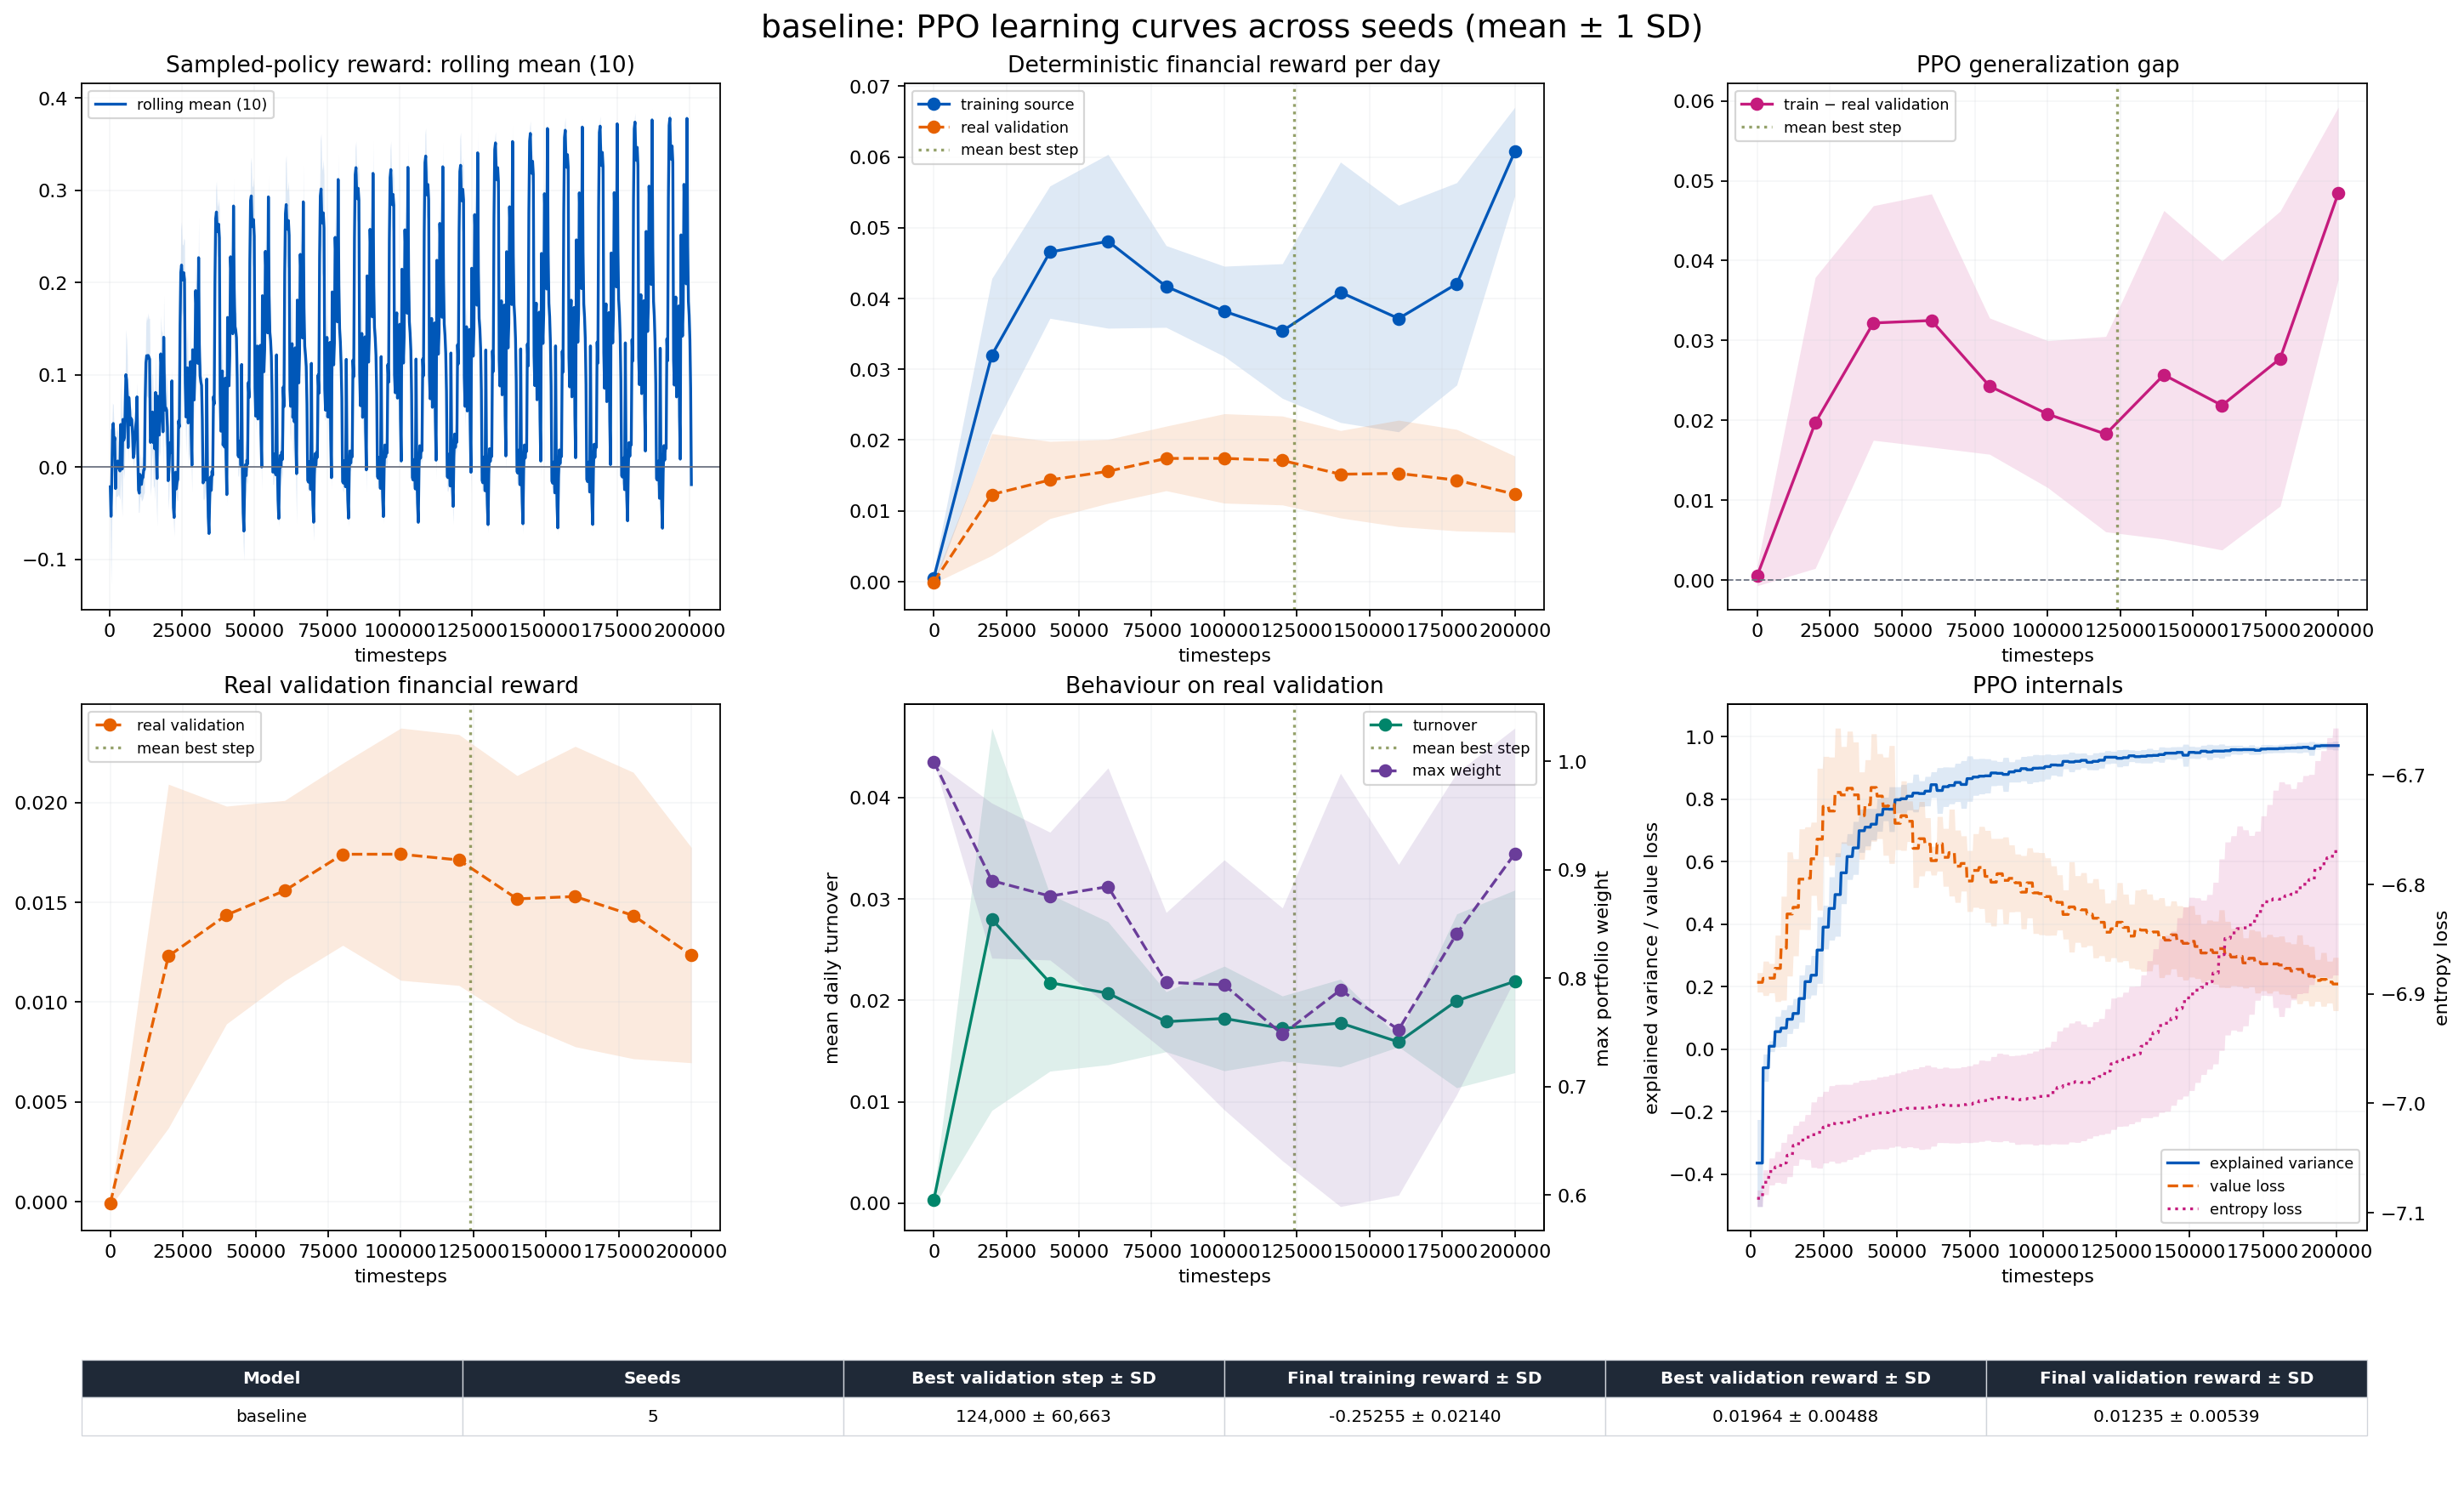

In [7]:
NotebookImage(filename=str(learning_paths["baseline"]))


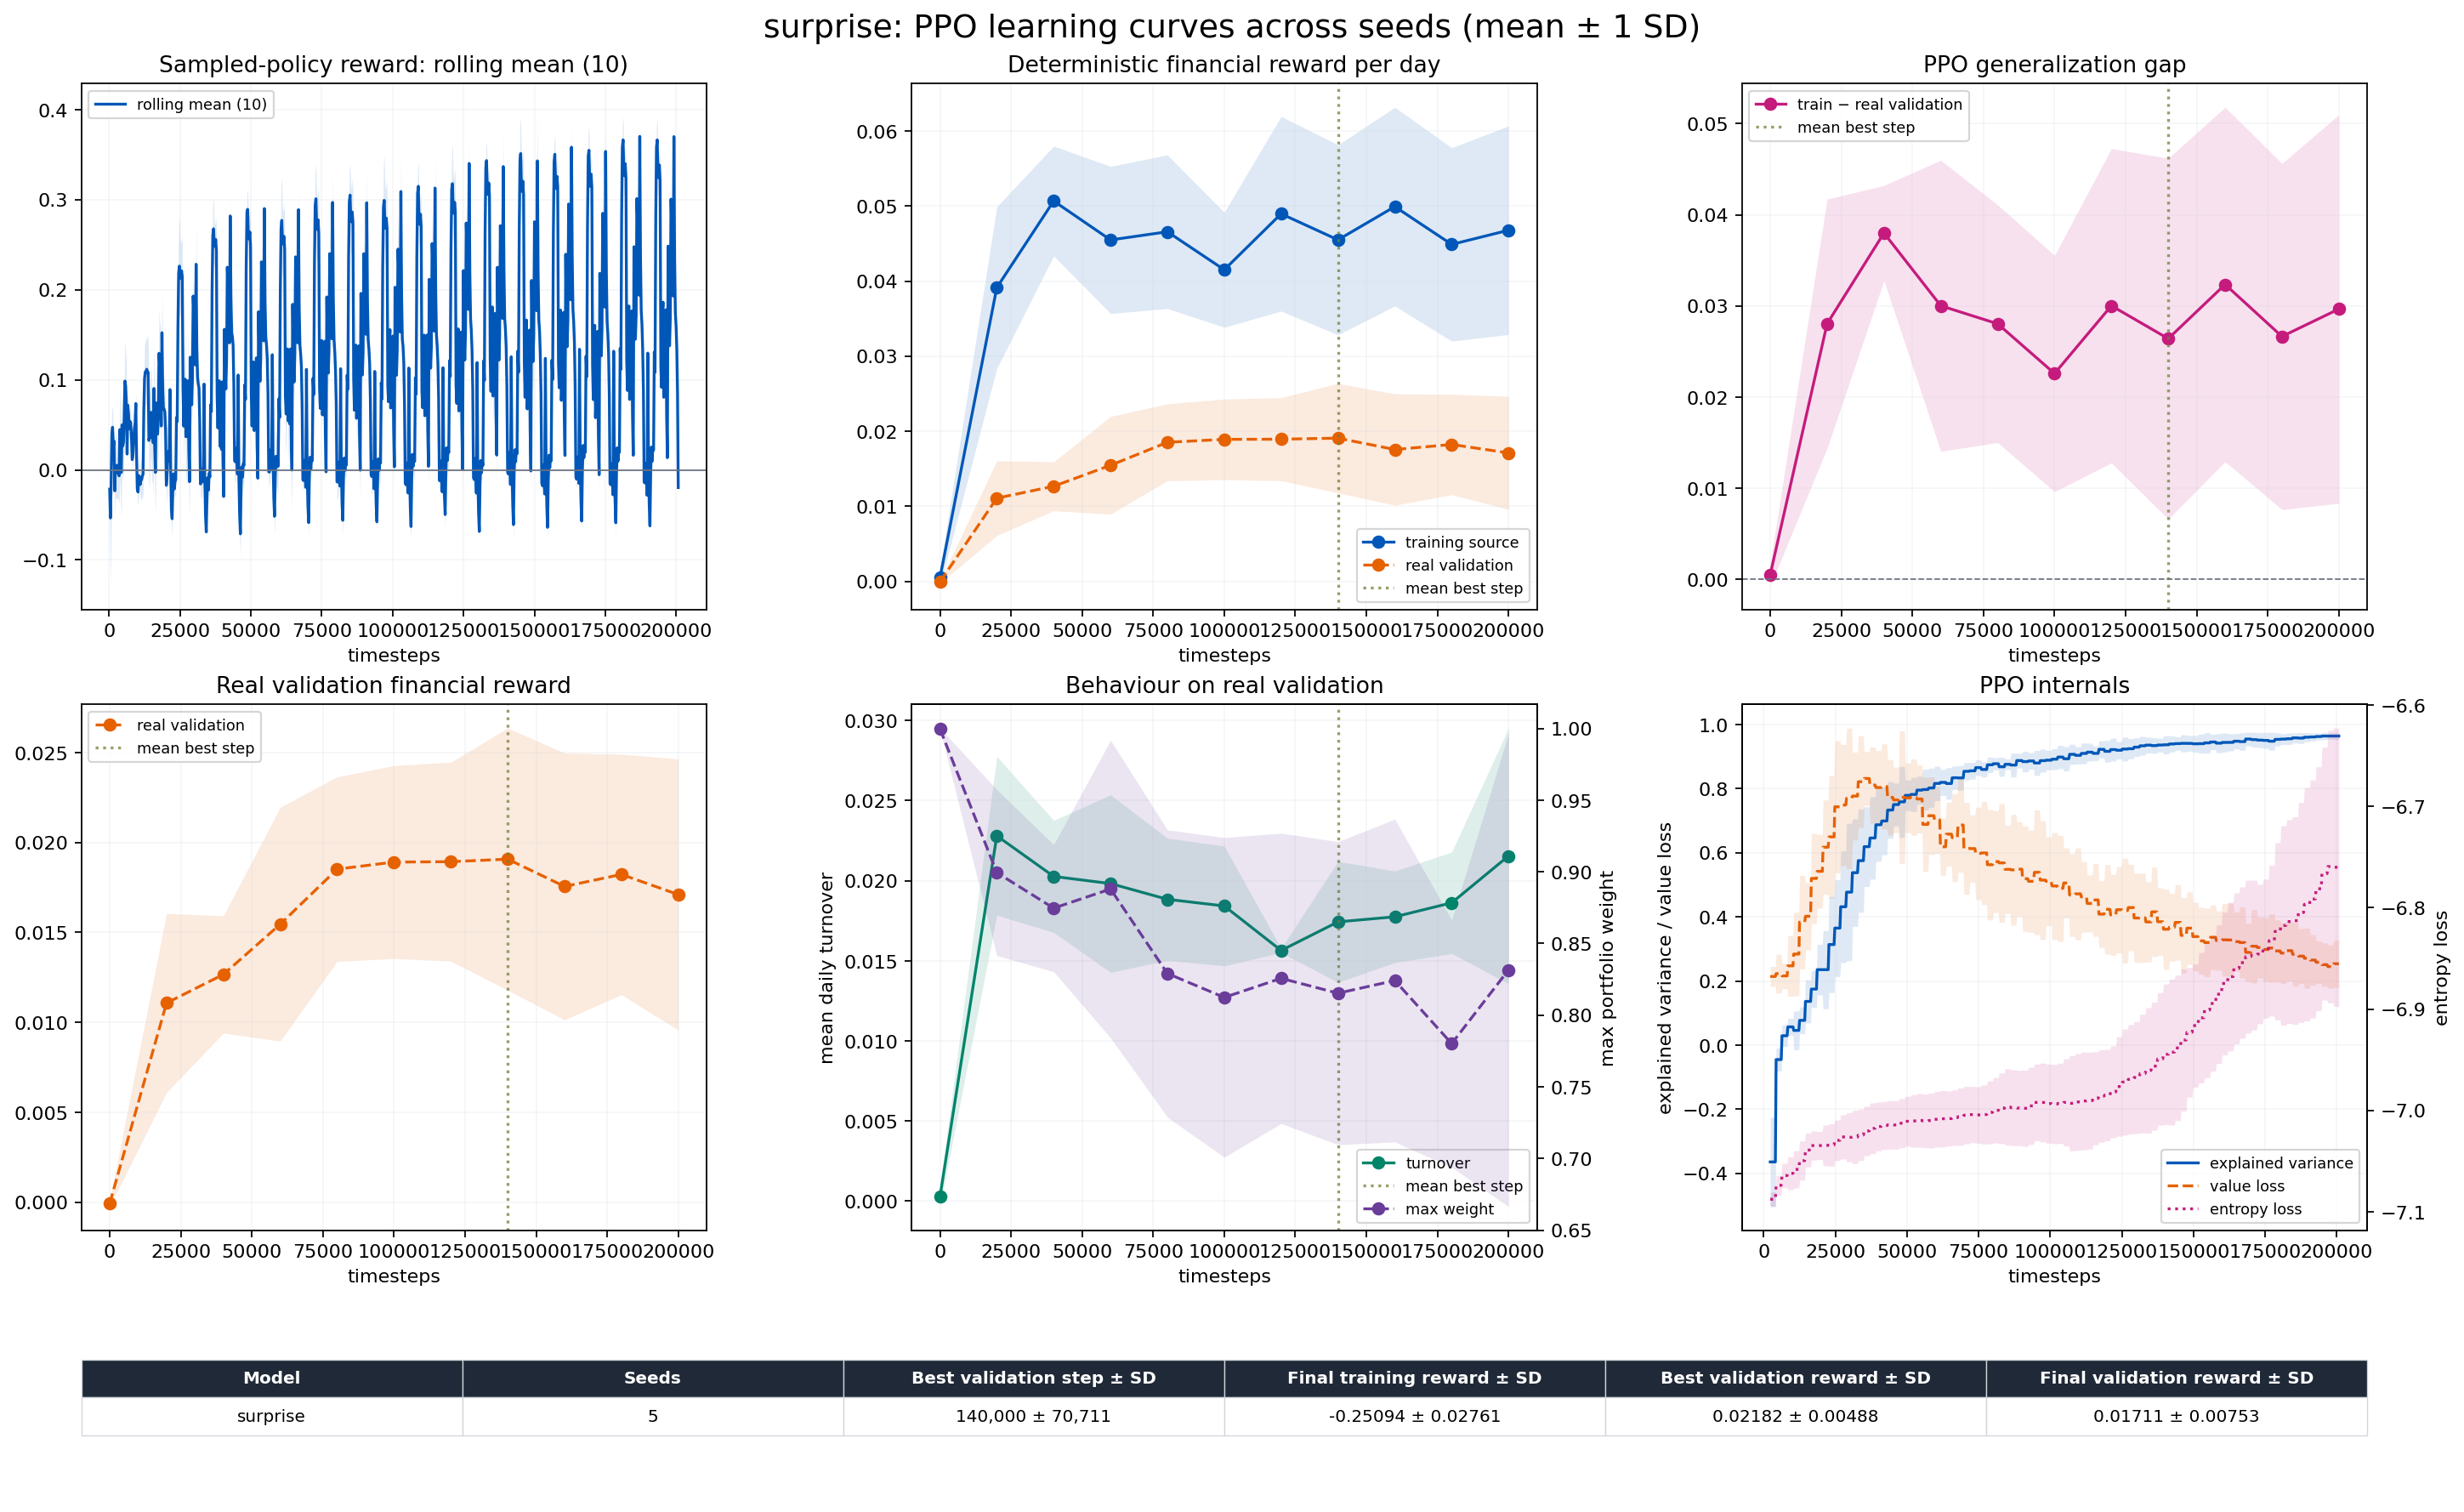

In [8]:
NotebookImage(filename=str(learning_paths["surprise"]))


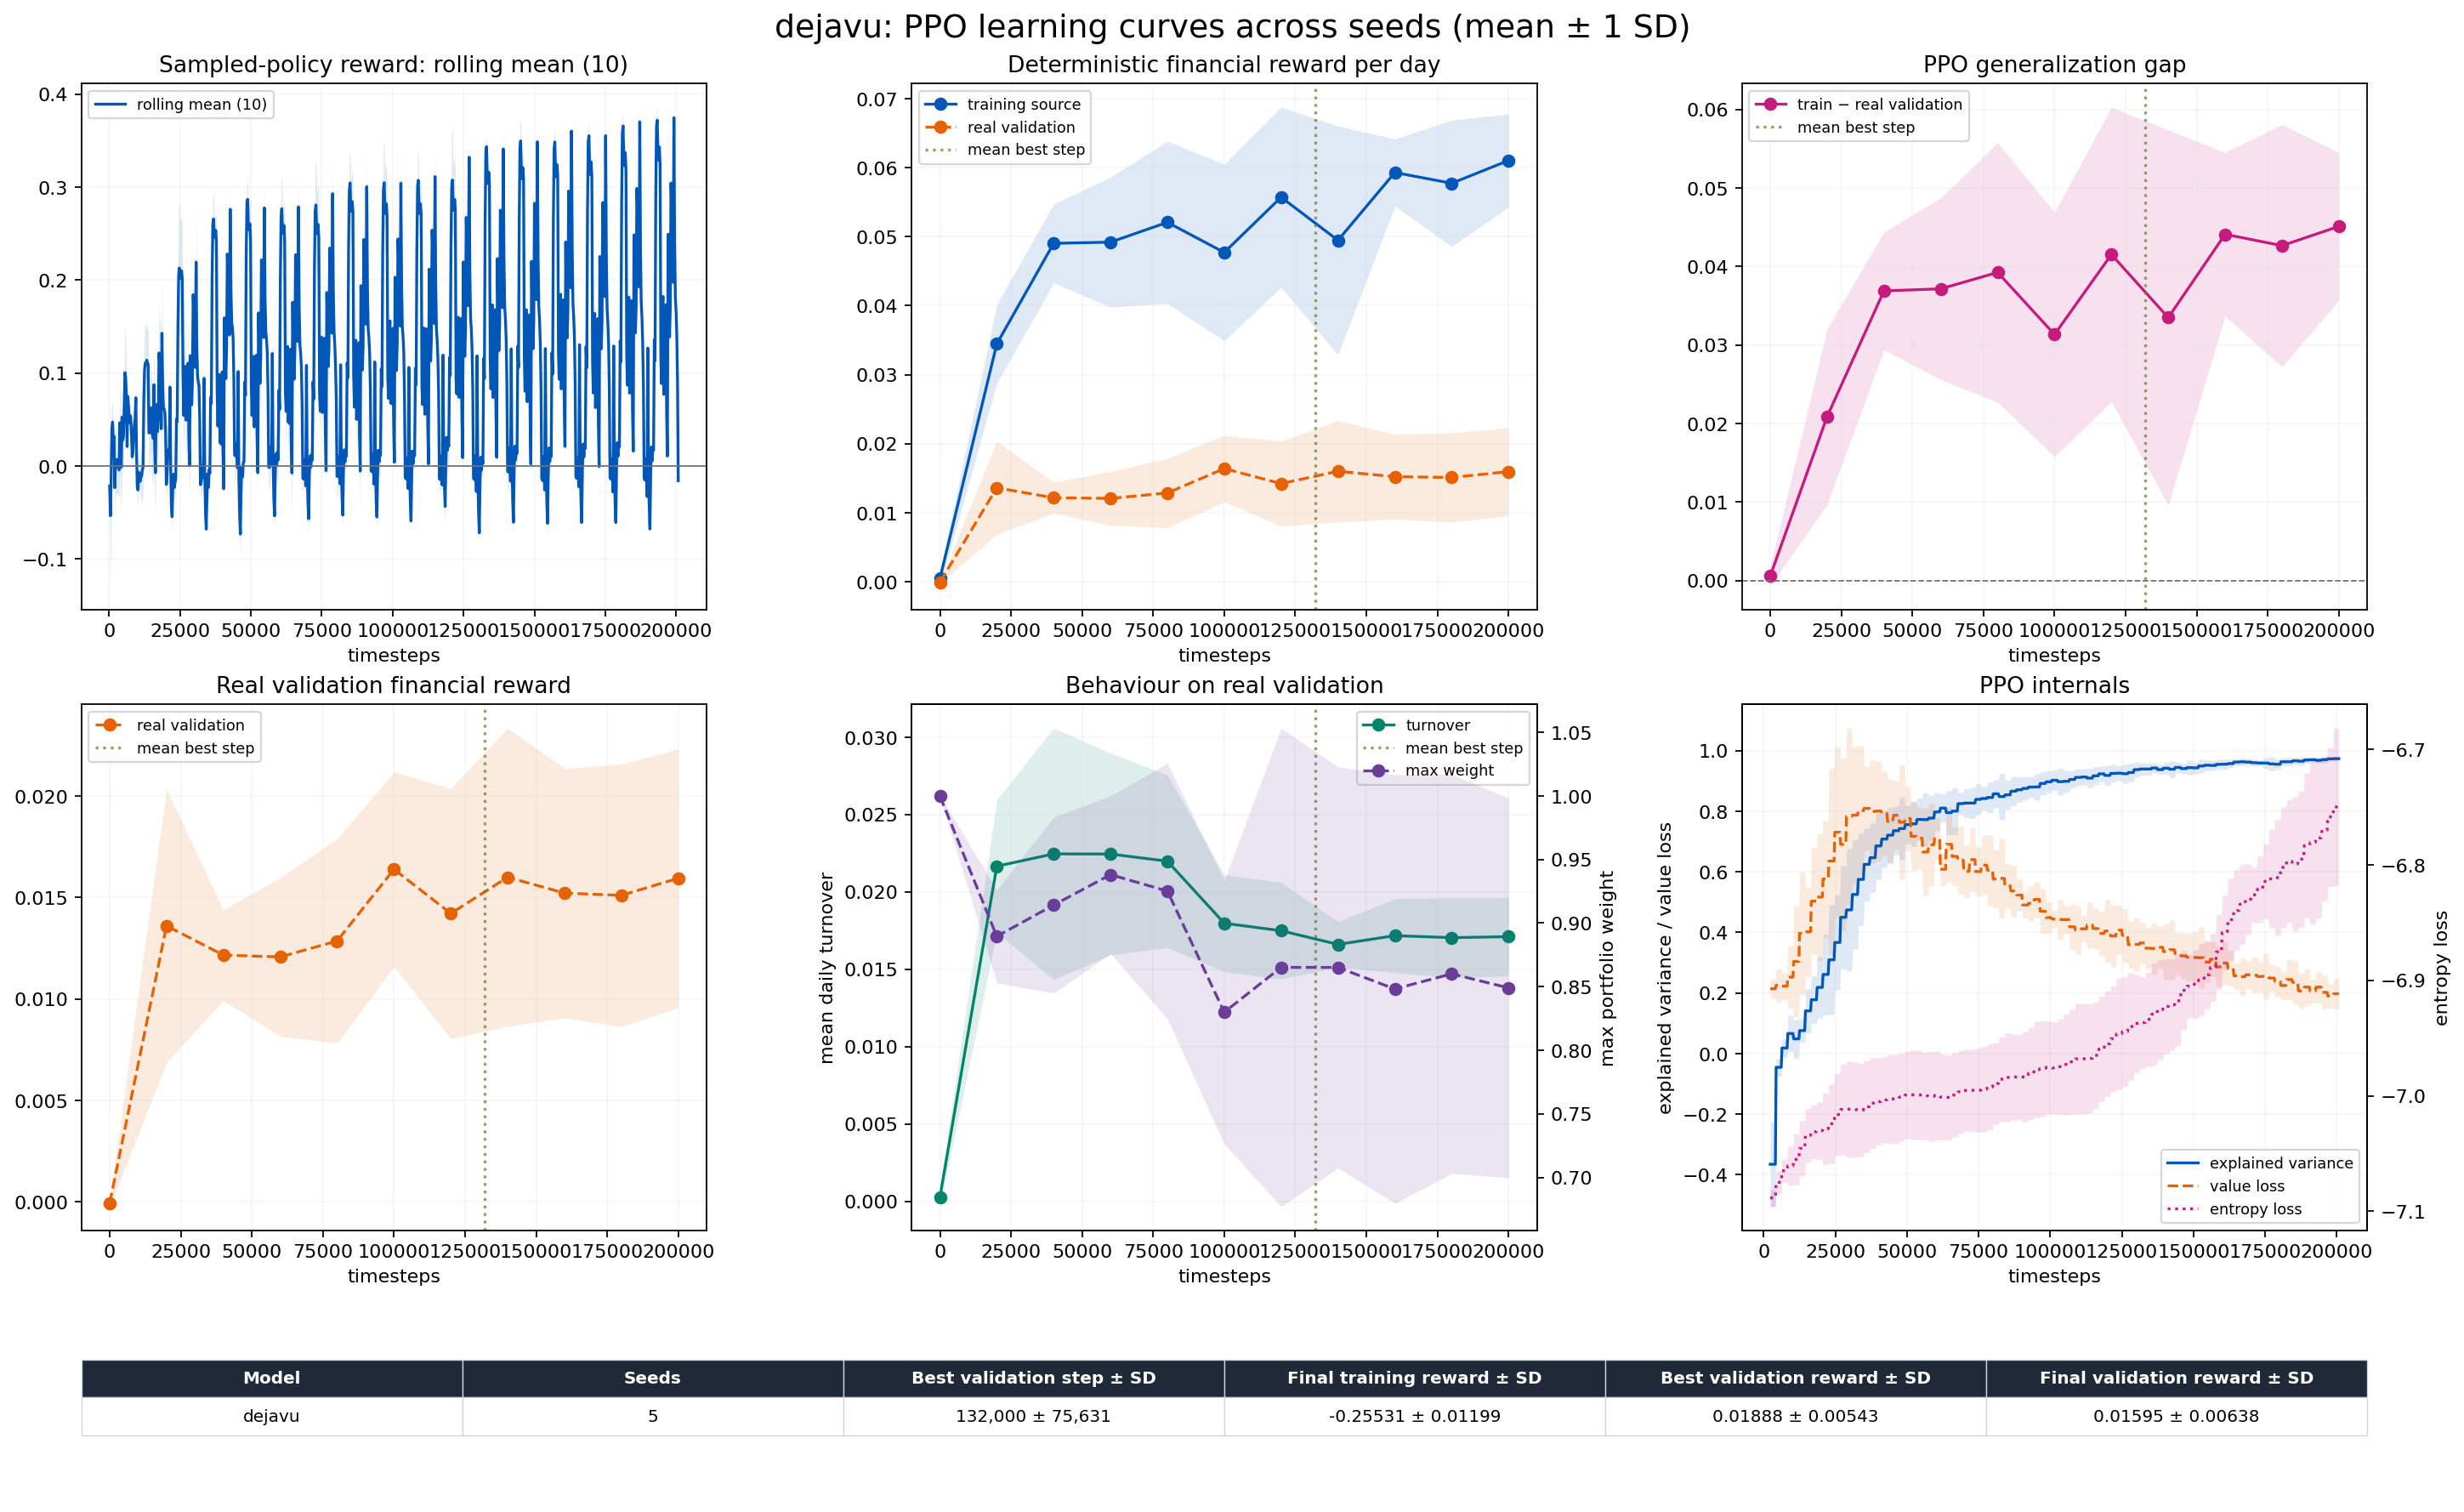

In [9]:
NotebookImage(filename=str(learning_paths["dejavu"]))


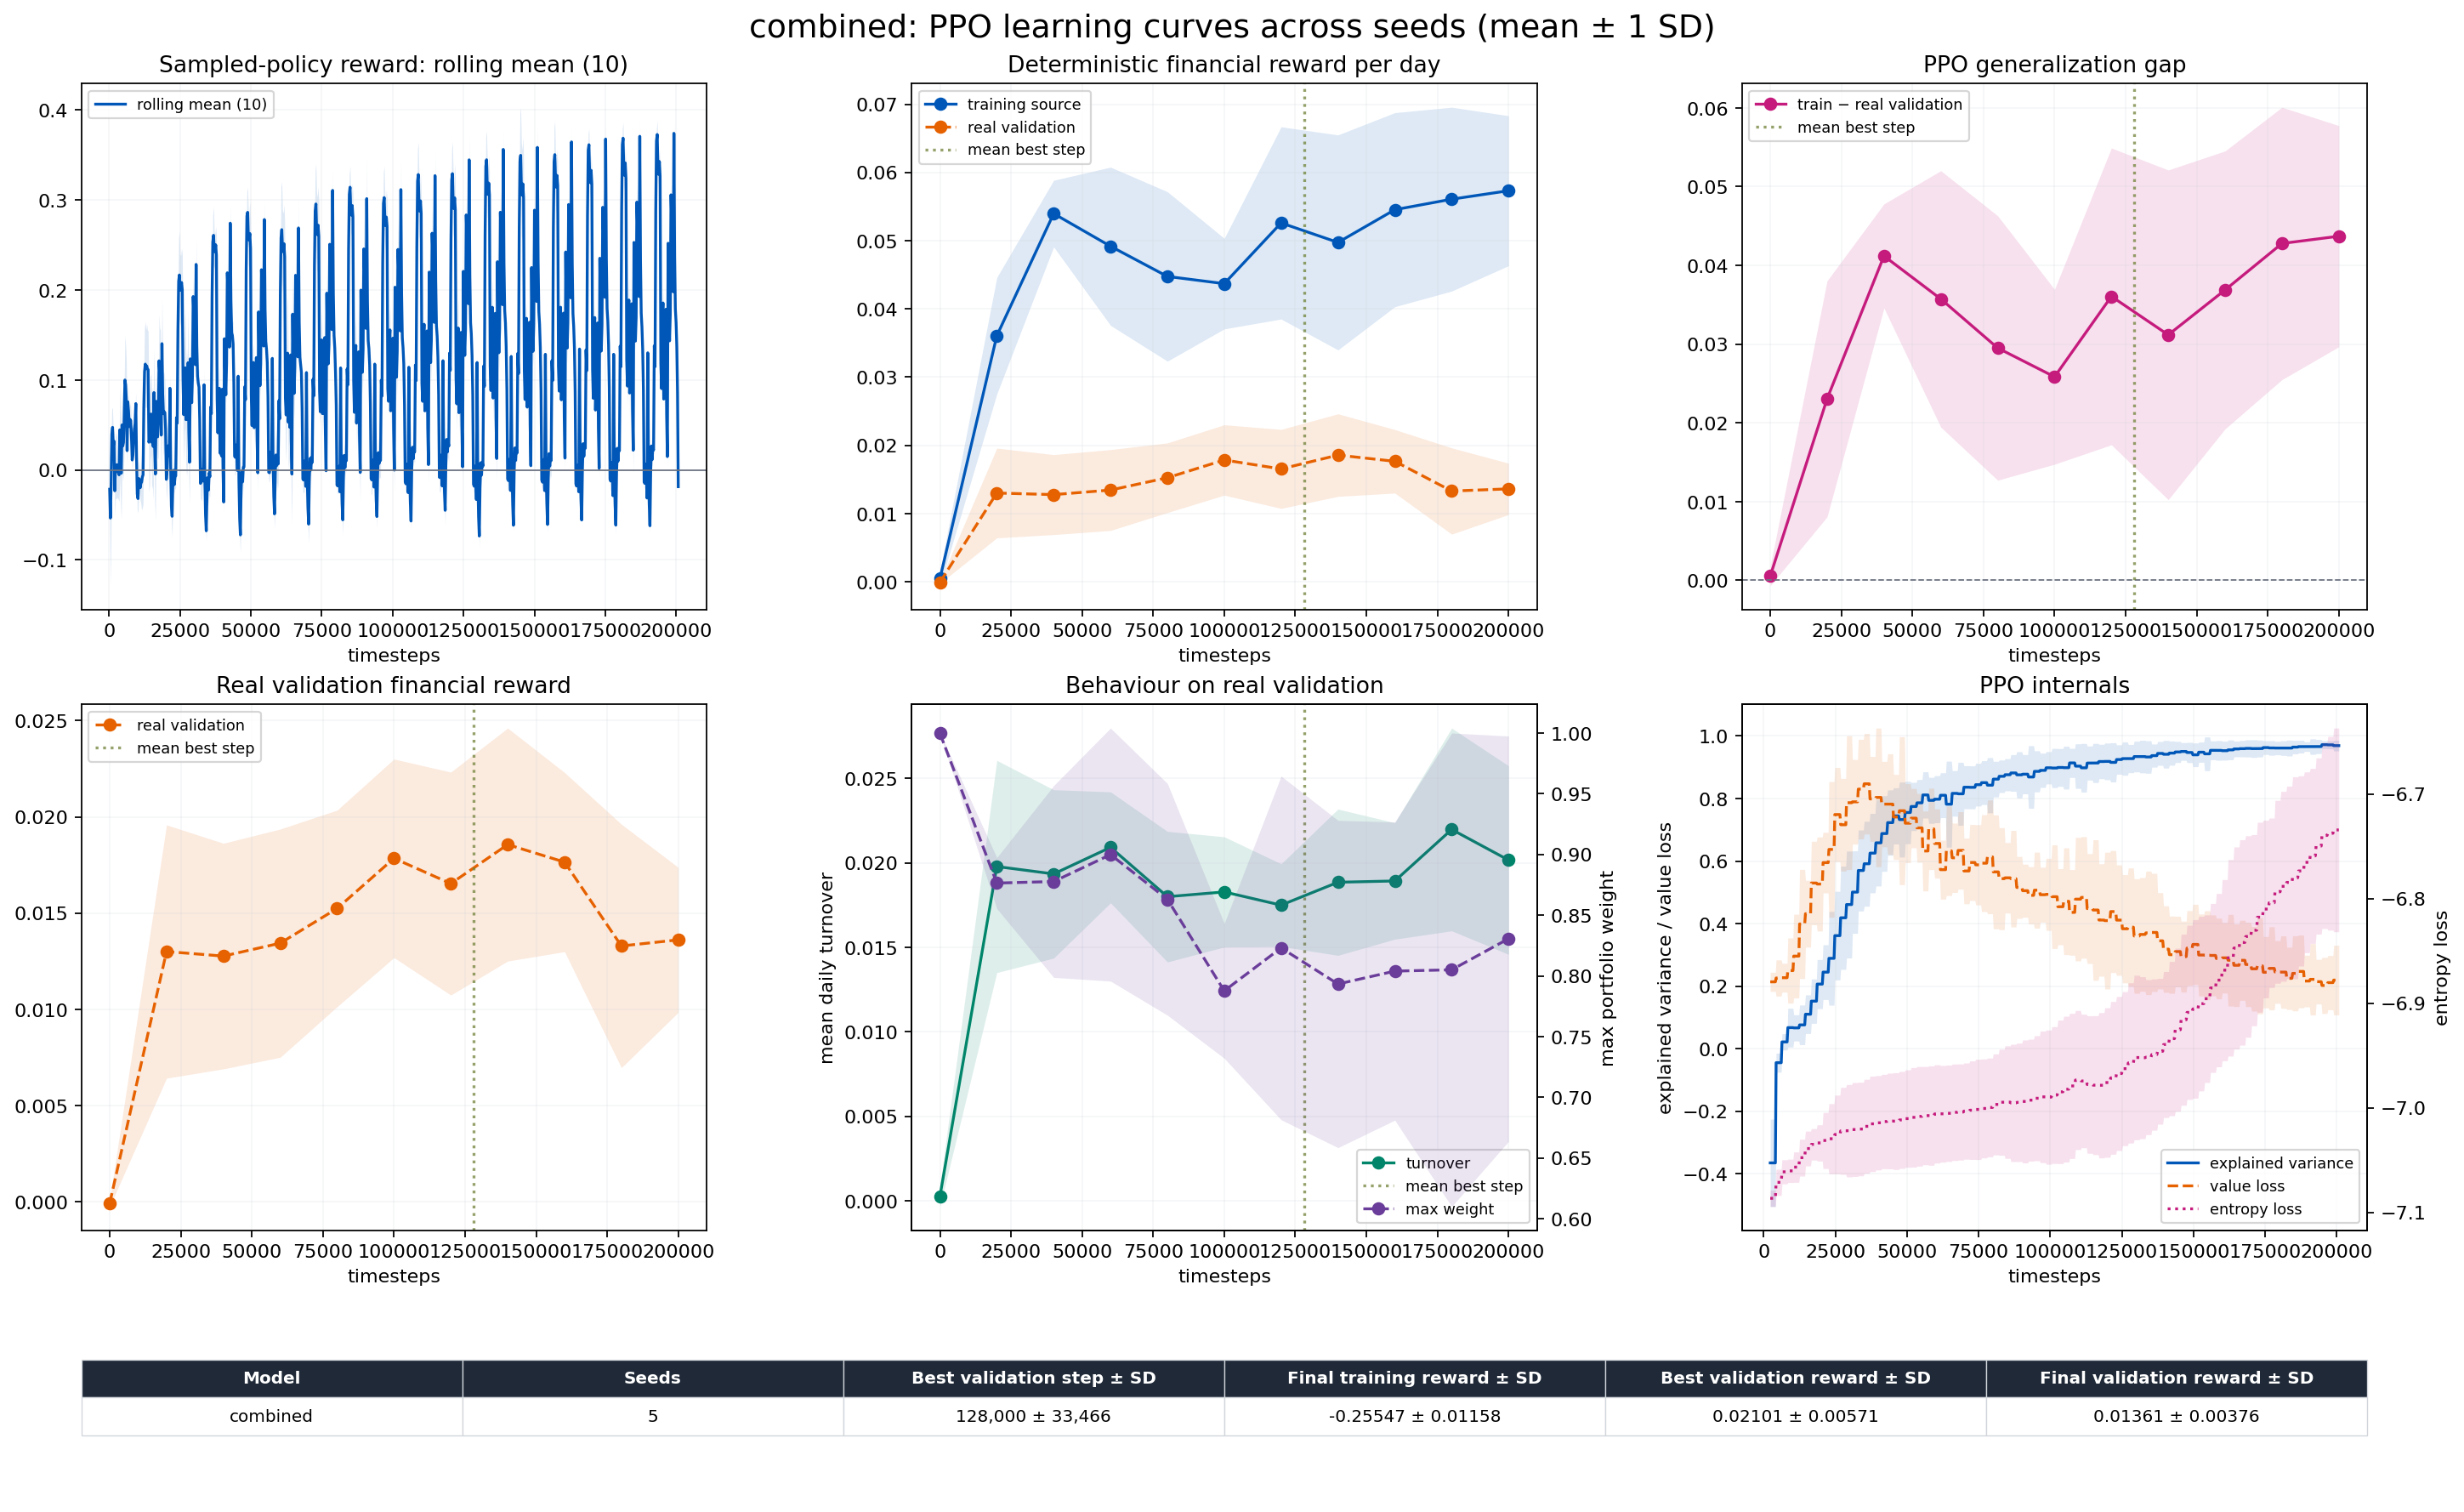

In [10]:
NotebookImage(filename=str(learning_paths["combined"]))


### Intrinsic-reward diagnostics (additional)

These panels are specific to this experiment and are intentionally separate
from the common PPO learning curves: external/intrinsic reward decomposition,
raw and scaled Surprise/Déjà vu bonuses, dynamic weighting, and novelty losses.


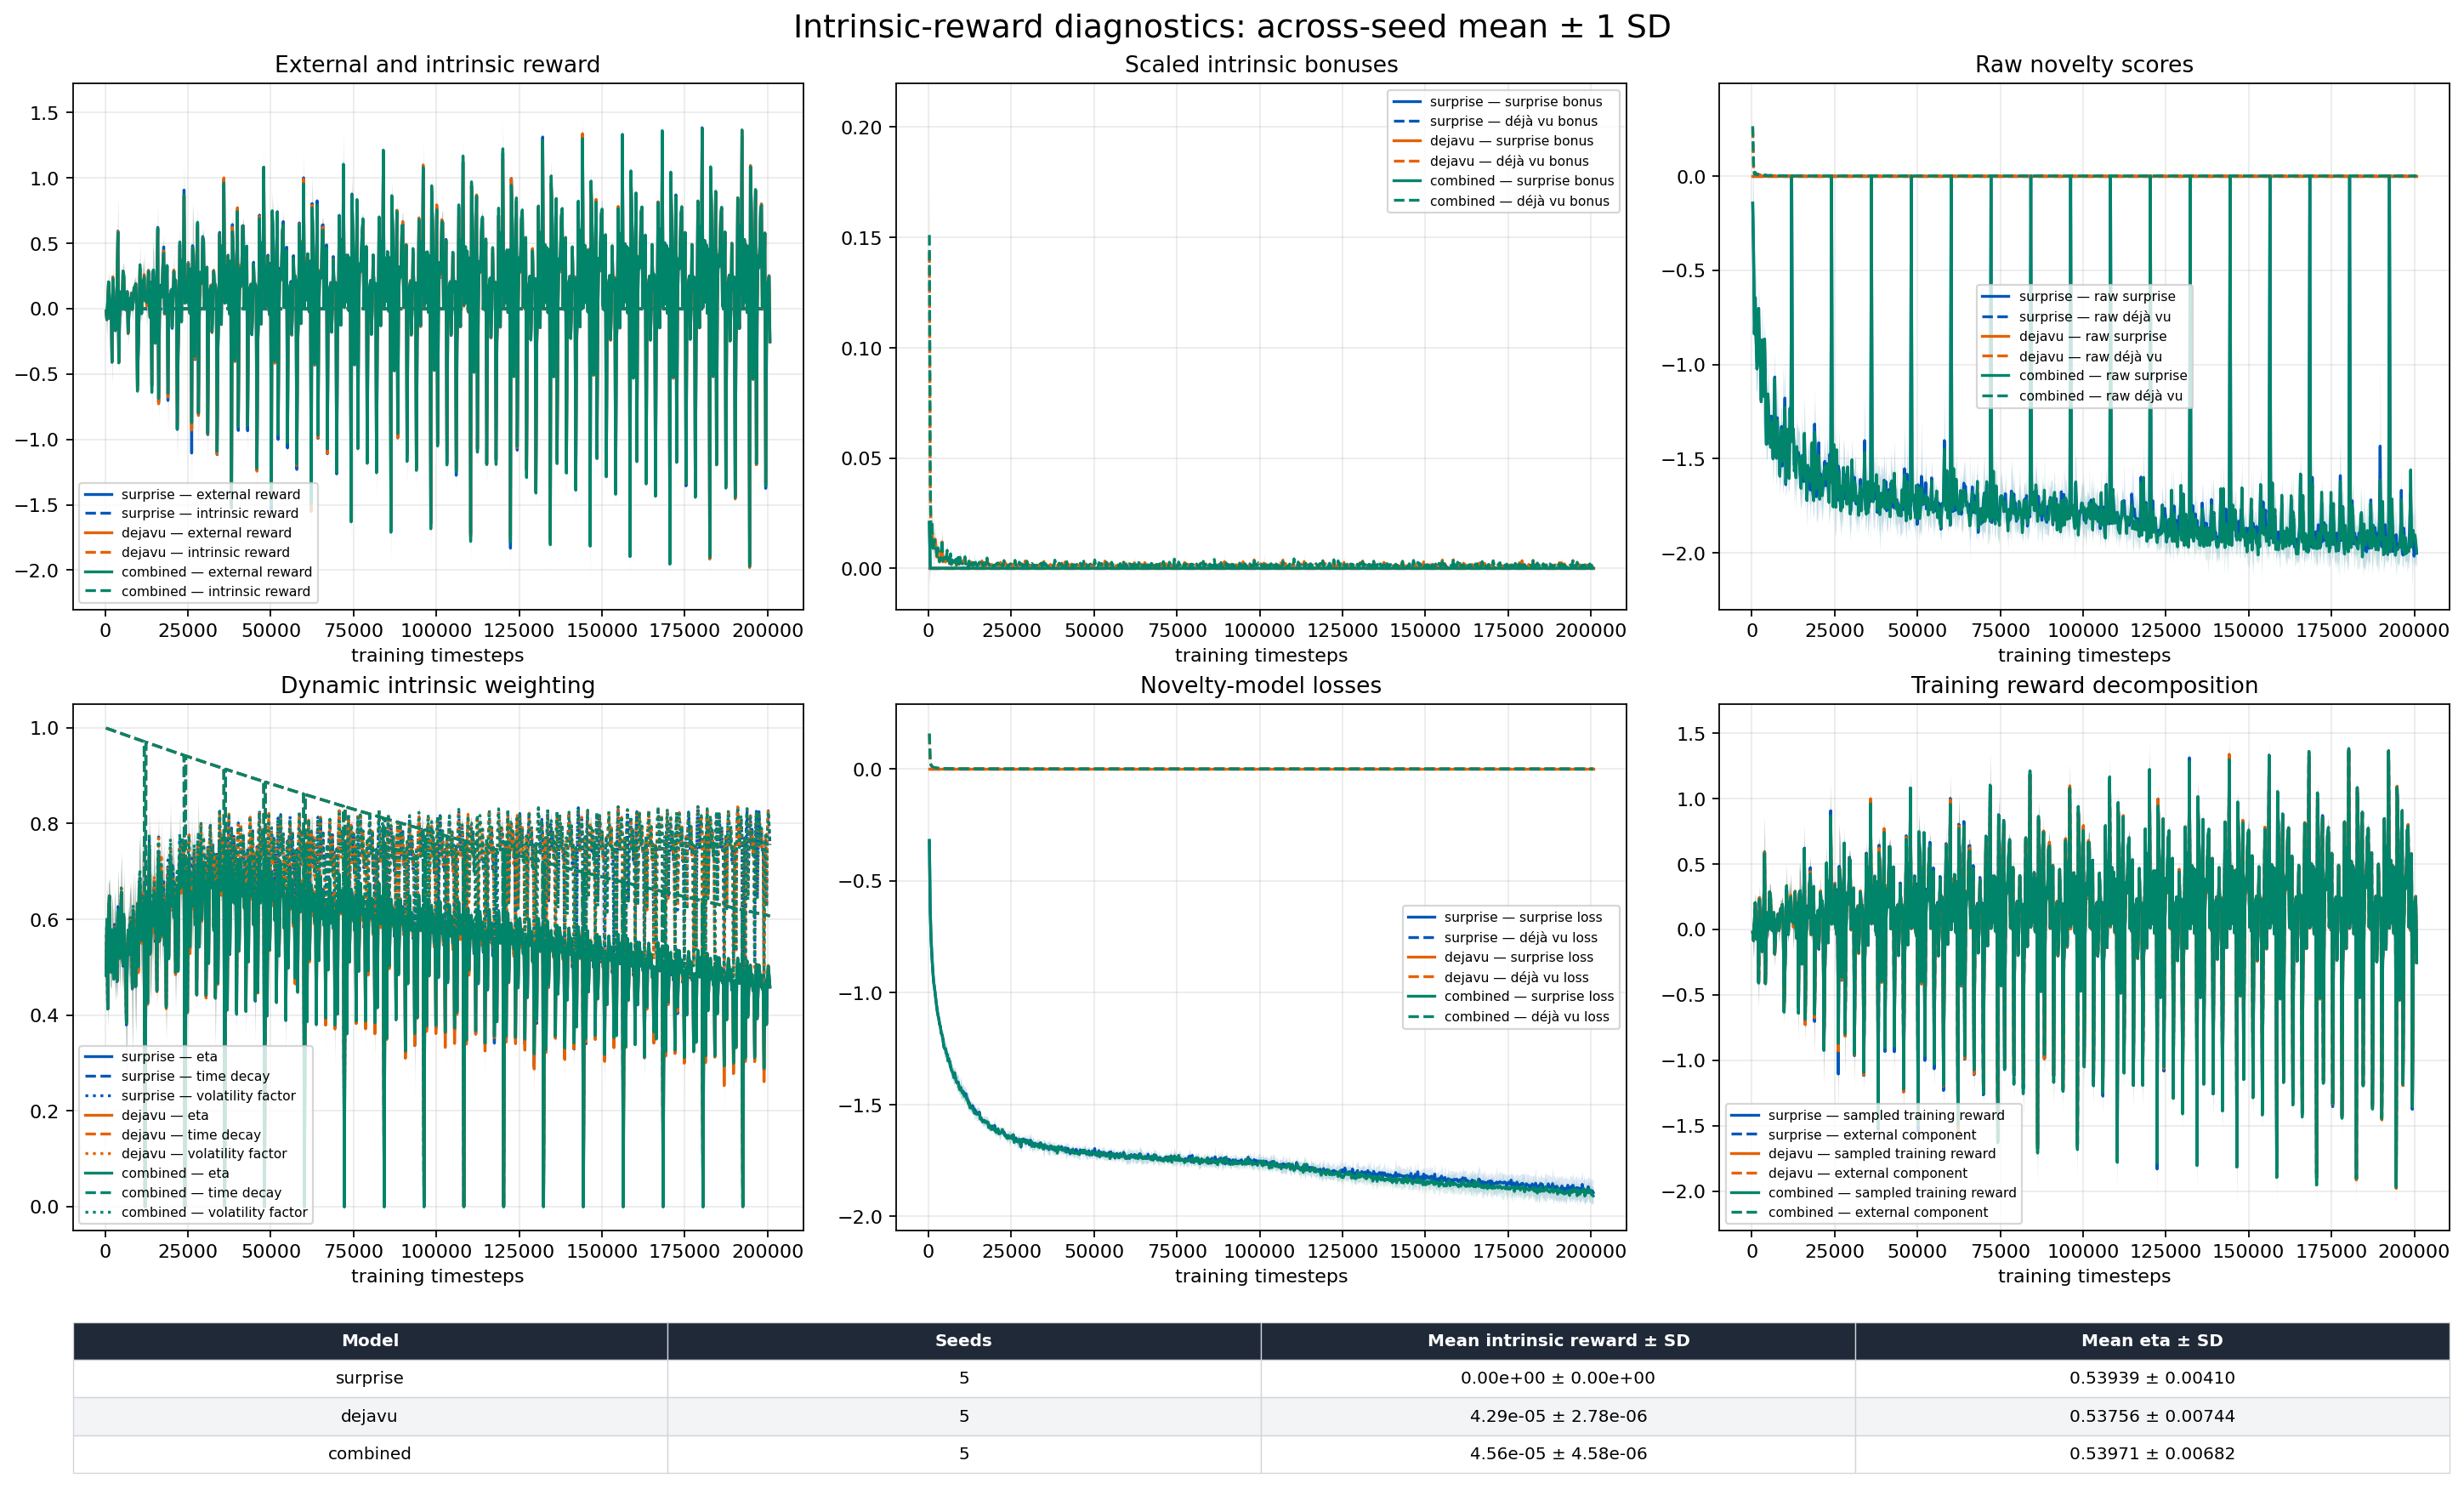

In [11]:
intrinsic_frames = []
for run in runs:
    if run.variant == "baseline" or run.intrinsic_log.empty:
        continue
    frame = run.intrinsic_log.copy()
    frame["variant"] = run.variant
    frame["seed"] = run.seed
    intrinsic_frames.append(frame)

intrinsic_log = pd.concat(intrinsic_frames, ignore_index=True)
(
    intrinsic_figure,
    intrinsic_curve_summary,
    intrinsic_model_summary,
) = plot_intrinsic_diagnostics(intrinsic_log)
intrinsic_path = ARTIFACT_ROOT / "intrinsic_reward_diagnostics.png"
intrinsic_figure.savefig(intrinsic_path, dpi=160, bbox_inches="tight")
plt.close(intrinsic_figure)
NotebookImage(filename=str(intrinsic_path))


## 5. External-reward backtests and Buy & Hold


In [12]:
(
    ppo_period_summary,
    period_results,
    buy_and_hold_summary,
    buy_and_hold_results,
) = evaluate_experiment_periods(periods, runs, ENV_KWARGS)

test_summary = ppo_period_summary.loc[
    ppo_period_summary["period"] == "test"
].reset_index(drop=True)
backtest_summary = pd.concat(
    [ppo_period_summary, buy_and_hold_summary], ignore_index=True
)
ppo_period_summary.to_csv(ARTIFACT_ROOT / "ppo_period_metrics.csv", index=False)
test_summary.to_csv(ARTIFACT_ROOT / "test_metrics.csv", index=False)
buy_and_hold_summary.to_csv(
    ARTIFACT_ROOT / "buy_and_hold_metrics.csv", index=False
)
backtest_summary.to_csv(
    ARTIFACT_ROOT / "backtest_results.csv", index=False
)
backtest_summary


,period,variant,seed,best_timestep,final_value,cumulative_return,cagr,sharpe,annualized_volatility,max_drawdown,turnover,reward_per_day
0,train,baseline,0,120000.0,161410.172134,0.614102,0.906366,2.072548,0.339223,-0.222794,0.005322,0.032840
1,train,surprise,0,180000.0,165890.278983,0.658903,0.978014,2.108686,0.353215,-0.226577,0.006401,0.035235
2,train,dejavu,0,200000.0,219591.741060,1.195917,1.886420,2.176873,0.558473,-0.270460,0.012953,0.063953
3,train,combined,0,100000.0,166287.118569,0.662871,0.984393,2.100960,0.356616,-0.227648,0.005286,0.035448
4,train,baseline,1,100000.0,171539.676514,0.715397,1.069323,2.124253,0.375733,-0.232435,0.005322,0.038257
...,...,...,...,...,...,...,...,...,...,...,...,...
58,test,dejavu,4,140000.0,114422.713873,0.144227,0.146086,0.557261,0.359608,-0.311373,0.004901,0.005792
59,test,combined,4,120000.0,114521.756631,0.145218,0.147090,0.560150,0.358767,-0.311478,0.003969,0.005832
60,train,buy_and_hold,<NA>,NaN,147737.640030,0.477376,0.692019,2.090566,0.269060,-0.191144,0.005342,0.025528
61,validation,buy_and_hold,<NA>,NaN,111488.299310,0.114883,0.544960,2.291932,0.198449,-0.041988,0.015857,0.018235


## 6. Backtest Sharpe and test metrics

The Sharpe plot retains every seed and marks the seed closest to each variant's
median test Sharpe with a diamond. The metric comparison uses all-seed mean ± SD
and includes deterministic Buy & Hold.


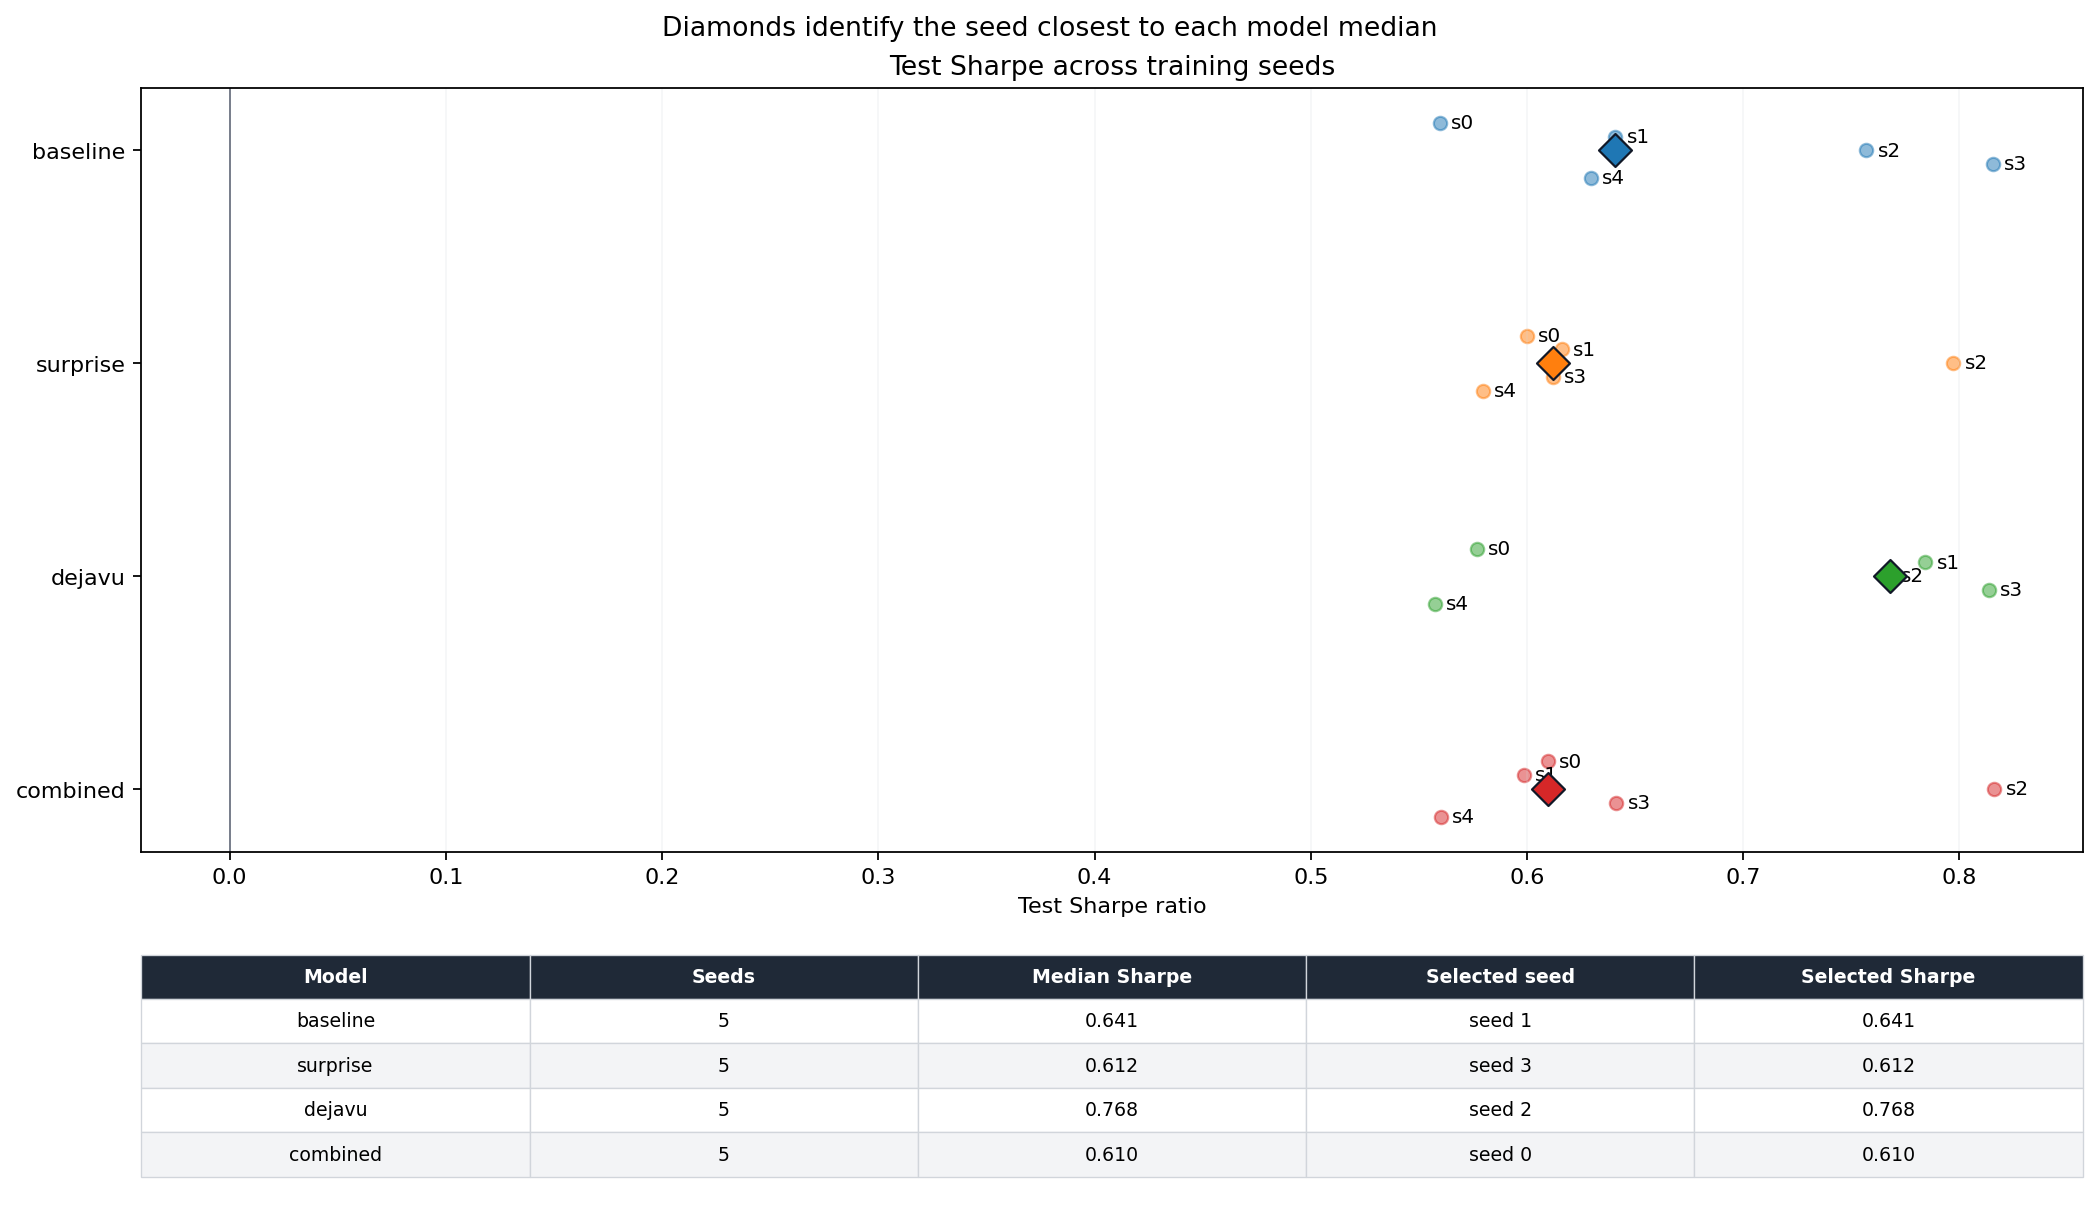

In [13]:
sharpe_figure, representative_test_runs = plot_sharpe_seed_selection(
    test_summary
)
representative_test_runs.to_csv(
    ARTIFACT_ROOT / "median_sharpe_representatives.csv", index=False
)
sharpe_path = ARTIFACT_ROOT / "median_sharpe_seed_selection.png"
sharpe_figure.savefig(sharpe_path, dpi=160, bbox_inches="tight")
plt.close(sharpe_figure)
NotebookImage(filename=str(sharpe_path))


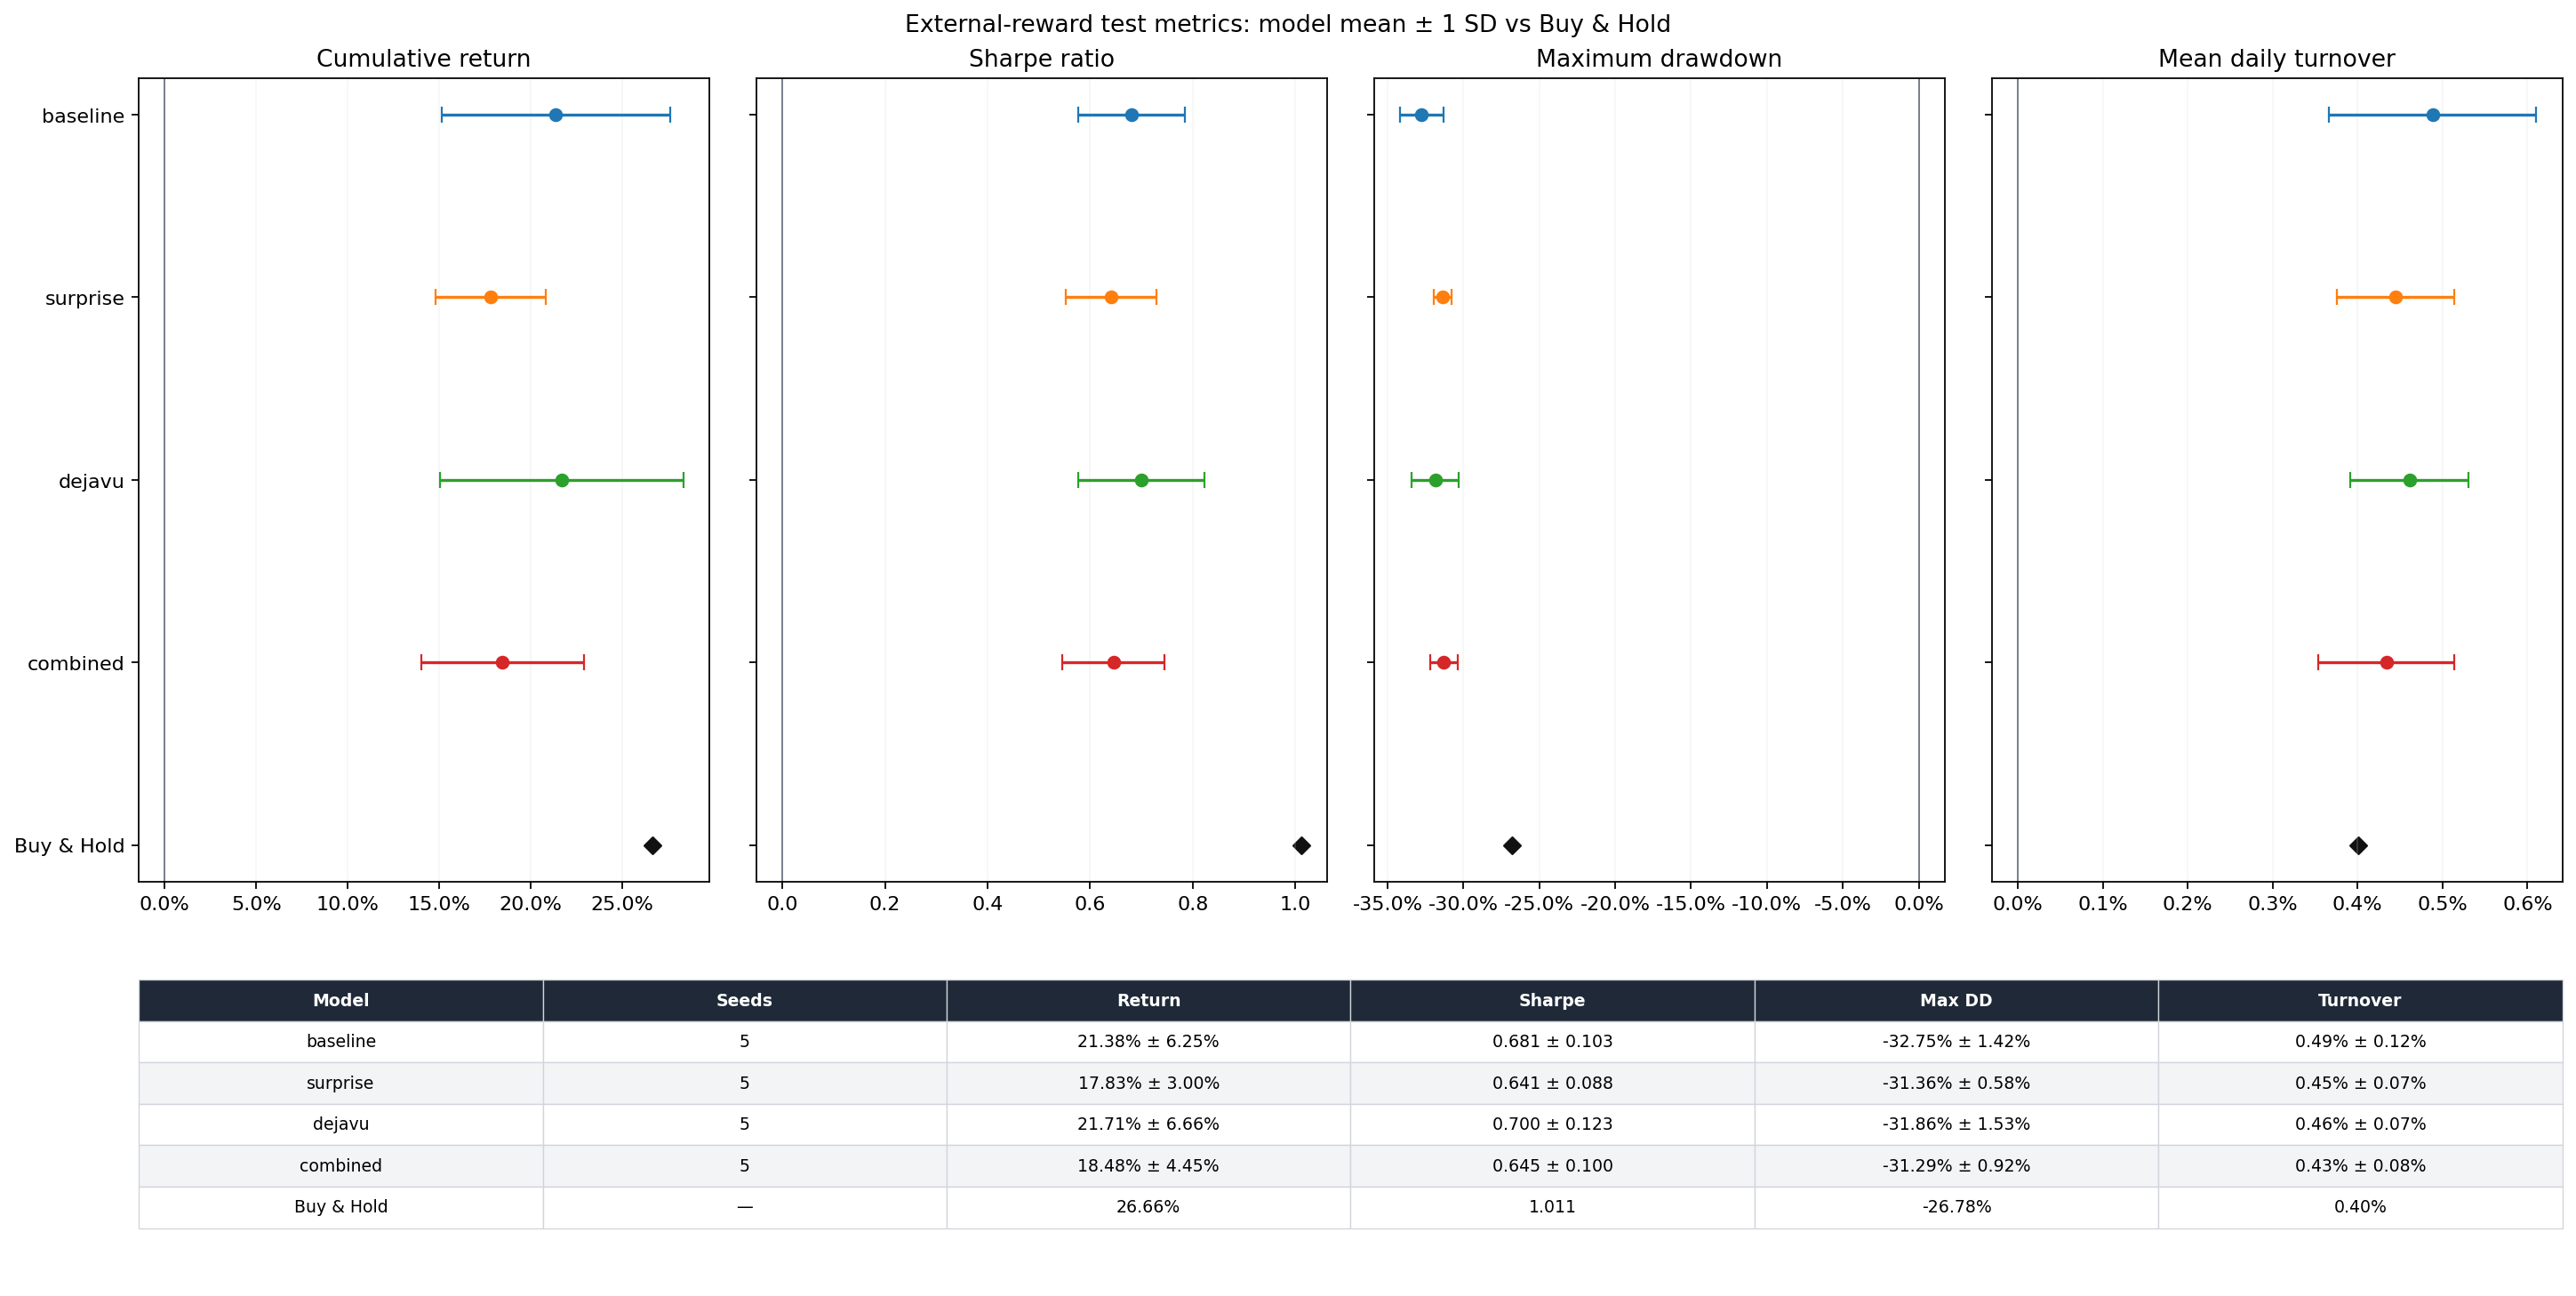

In [14]:
test_buy_and_hold = buy_and_hold_summary.loc[
    buy_and_hold_summary["period"] == "test"
].iloc[0]
metrics_figure, test_model_summary = plot_test_metric_comparison(
    test_summary, test_buy_and_hold
)
test_model_summary.to_csv(
    ARTIFACT_ROOT / "test_metrics_aggregated.csv", index=False
)
metrics_path = ARTIFACT_ROOT / "test_metrics_vs_buy_and_hold.png"
metrics_figure.savefig(metrics_path, dpi=160, bbox_inches="tight")
plt.close(metrics_figure)
NotebookImage(filename=str(metrics_path))


## 7. Train, validation, and test plots

All equity curves use Growth of $1. PPO variants are aggregated across seeds as
mean ± SD; Buy & Hold is the dashed black line. Each figure includes an exact
ranking table.


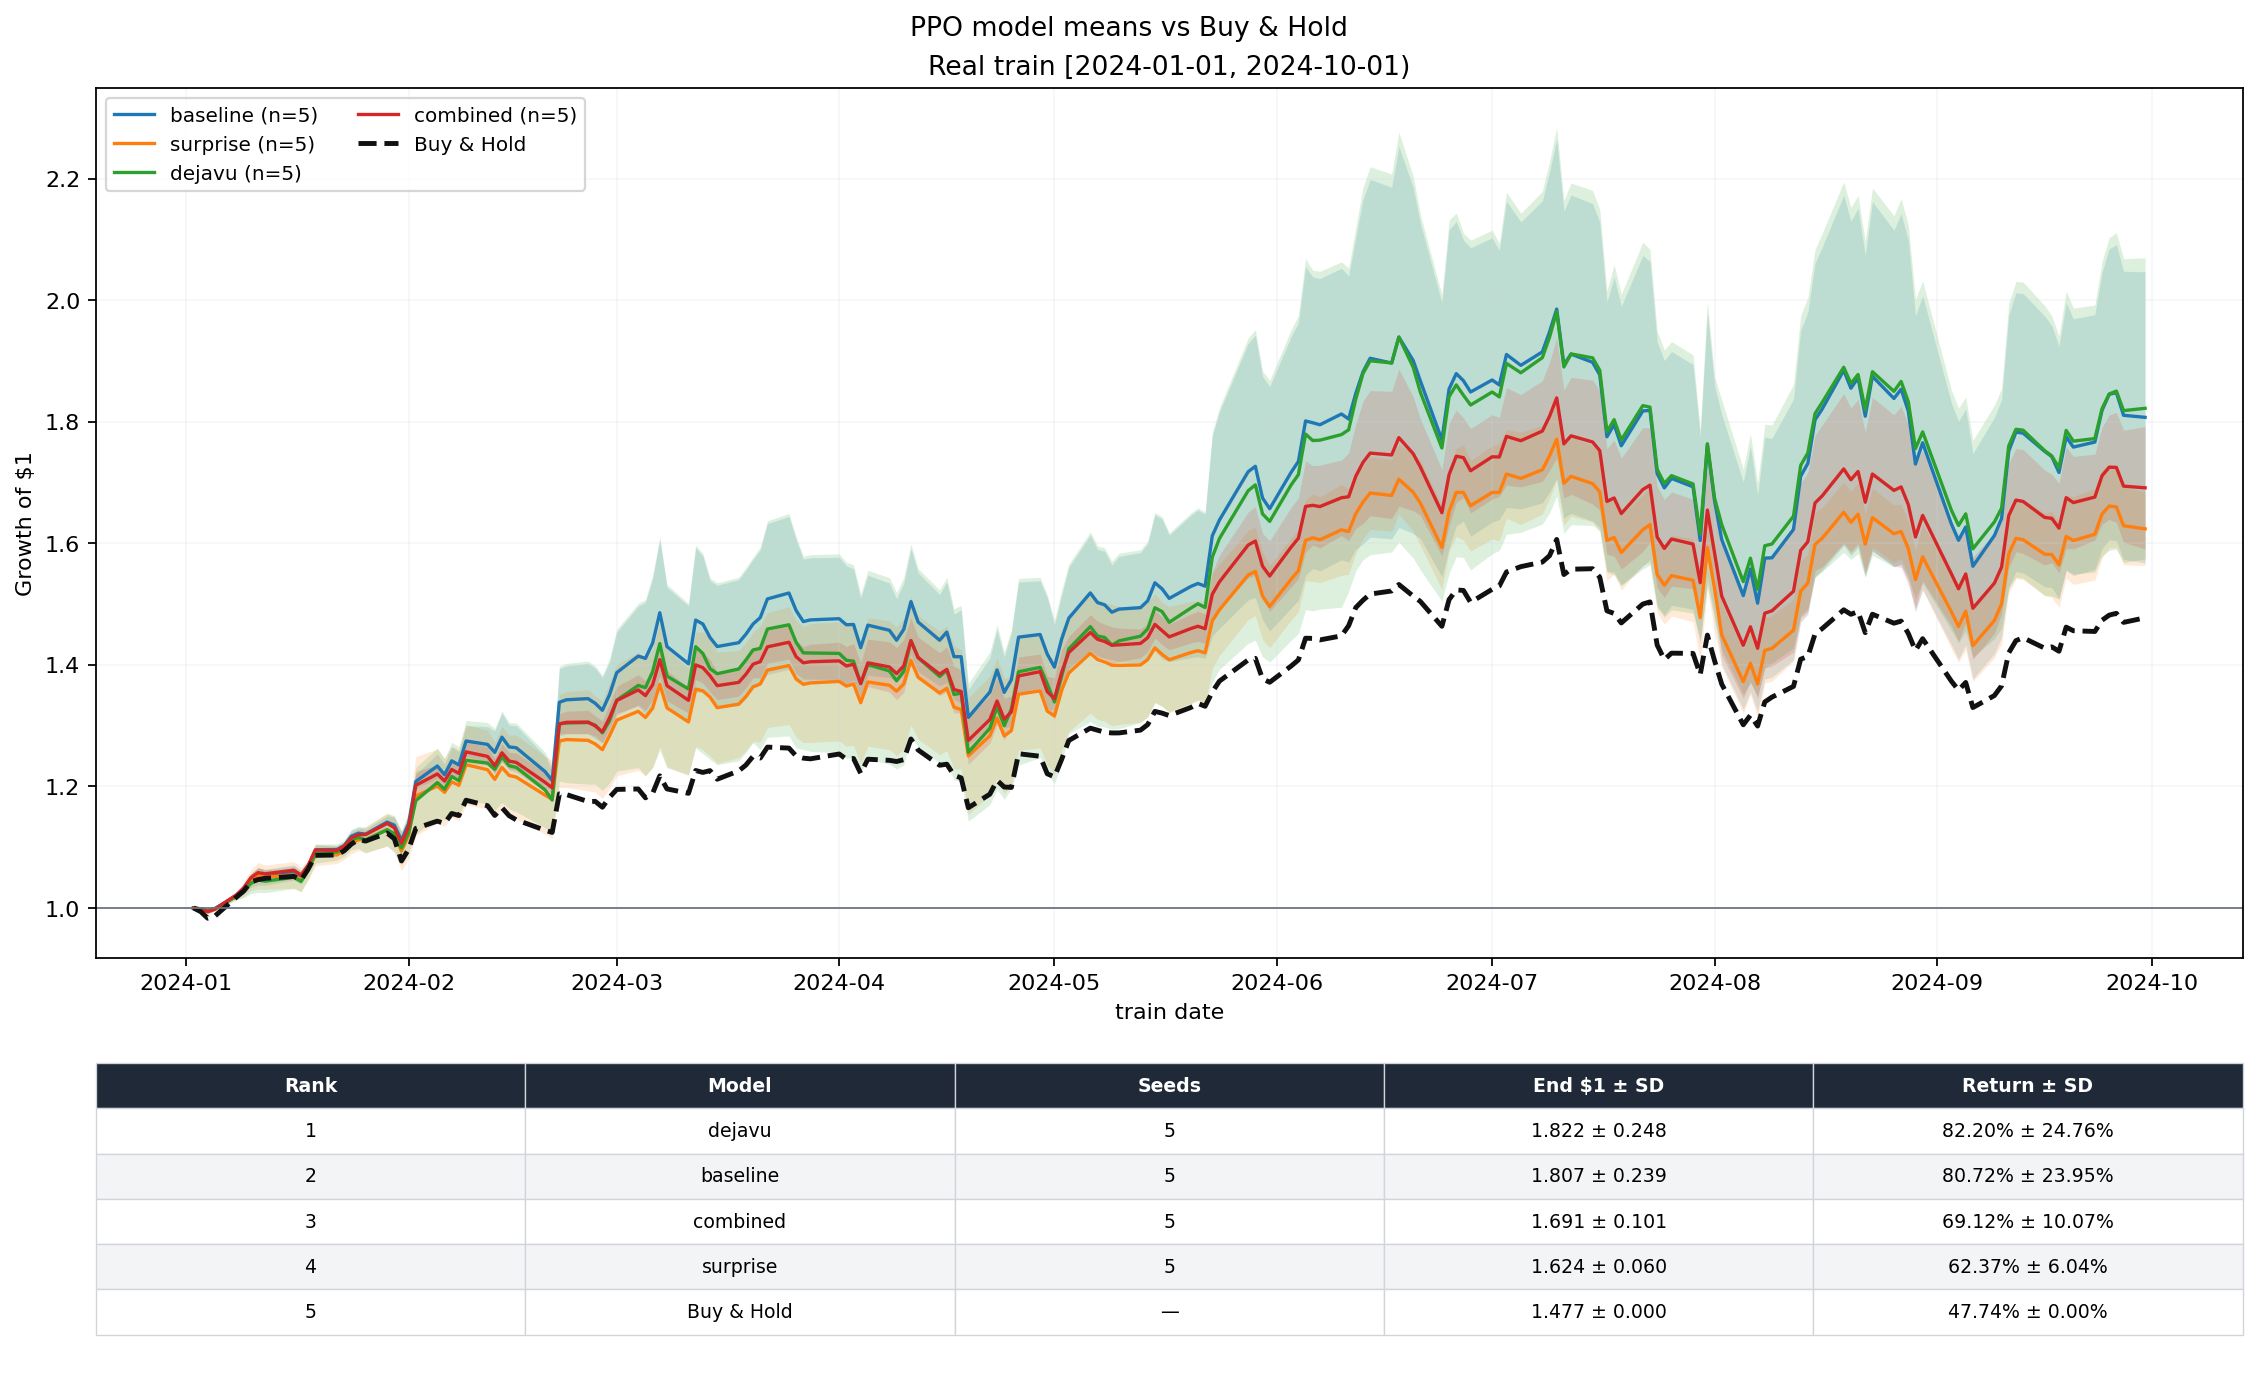

In [15]:
train_figure, train_equity, train_ranking = plot_period_equity_comparison(
    "train",
    period_results["train"],
    buy_and_hold_results["train"],
    f"Real train [{TRAIN_START}, {TRAIN_END})",
)
train_path = ARTIFACT_ROOT / "ppo_vs_buy_and_hold_train_equity_curves.png"
train_figure.savefig(train_path, dpi=160, bbox_inches="tight")
plt.close(train_figure)
train_equity.to_csv(ARTIFACT_ROOT / "train_equity_curves.csv", index=False)
train_ranking.to_csv(ARTIFACT_ROOT / "train_equity_ranking.csv", index=False)
NotebookImage(filename=str(train_path))


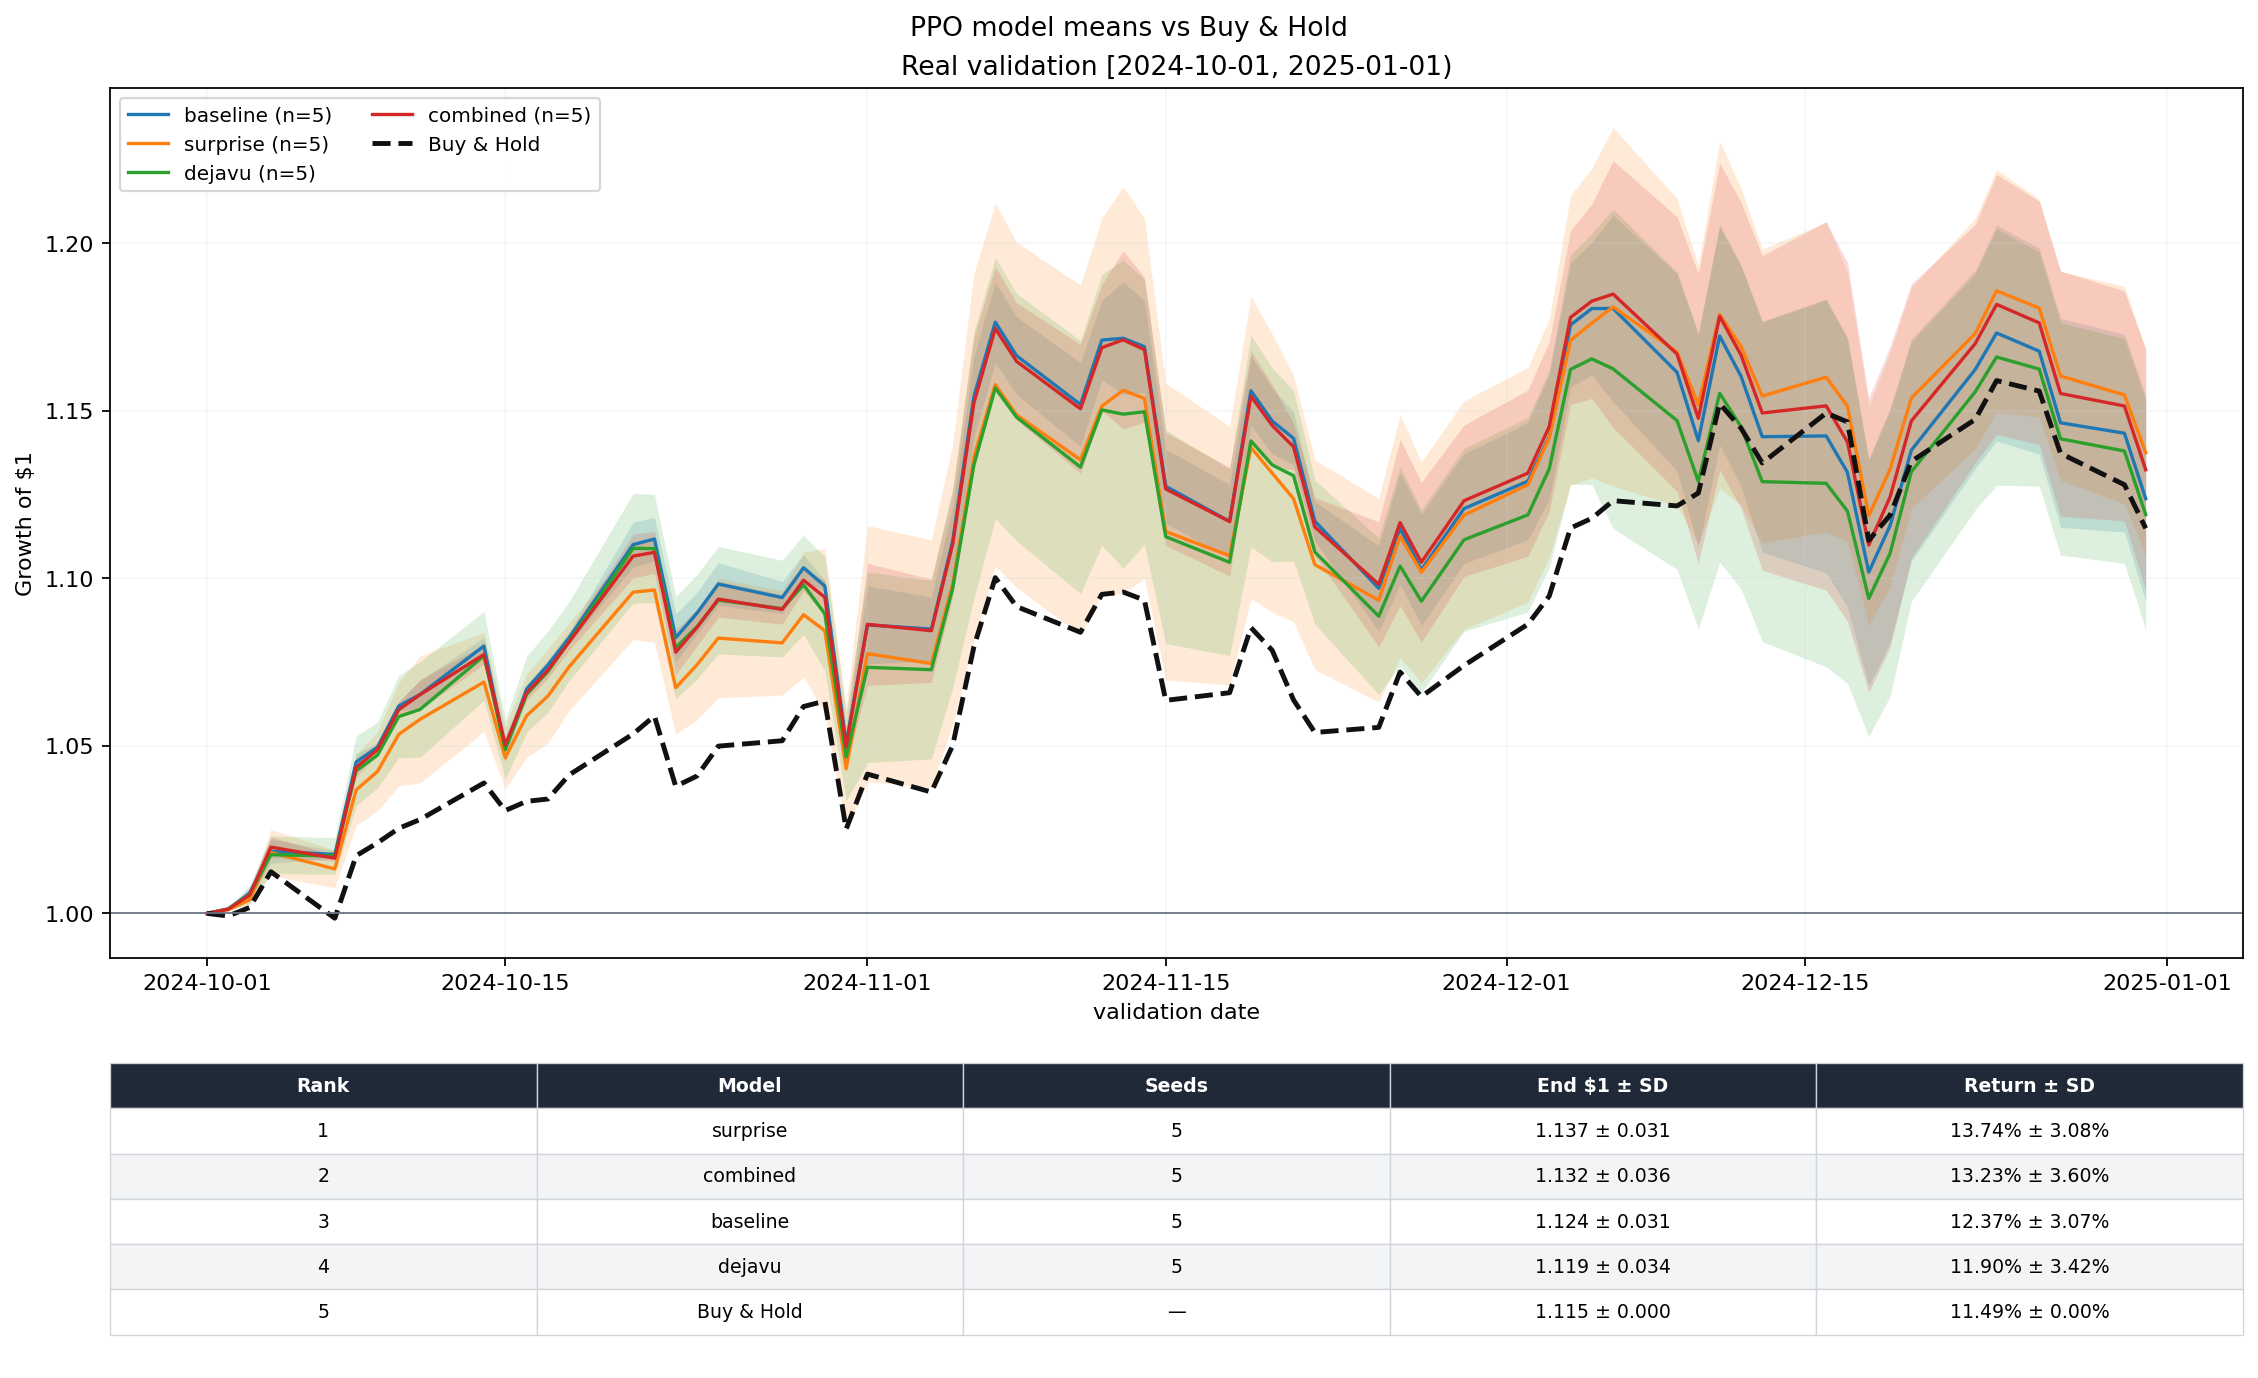

In [16]:
validation_figure, validation_equity, validation_ranking = (
    plot_period_equity_comparison(
        "validation",
        period_results["validation"],
        buy_and_hold_results["validation"],
        f"Real validation [{VALIDATION_START}, {VALIDATION_END})",
    )
)
validation_path = ARTIFACT_ROOT / "ppo_vs_buy_and_hold_validation_equity_curves.png"
validation_figure.savefig(validation_path, dpi=160, bbox_inches="tight")
plt.close(validation_figure)
validation_equity.to_csv(
    ARTIFACT_ROOT / "validation_equity_curves.csv", index=False
)
validation_ranking.to_csv(
    ARTIFACT_ROOT / "validation_equity_ranking.csv", index=False
)
NotebookImage(filename=str(validation_path))


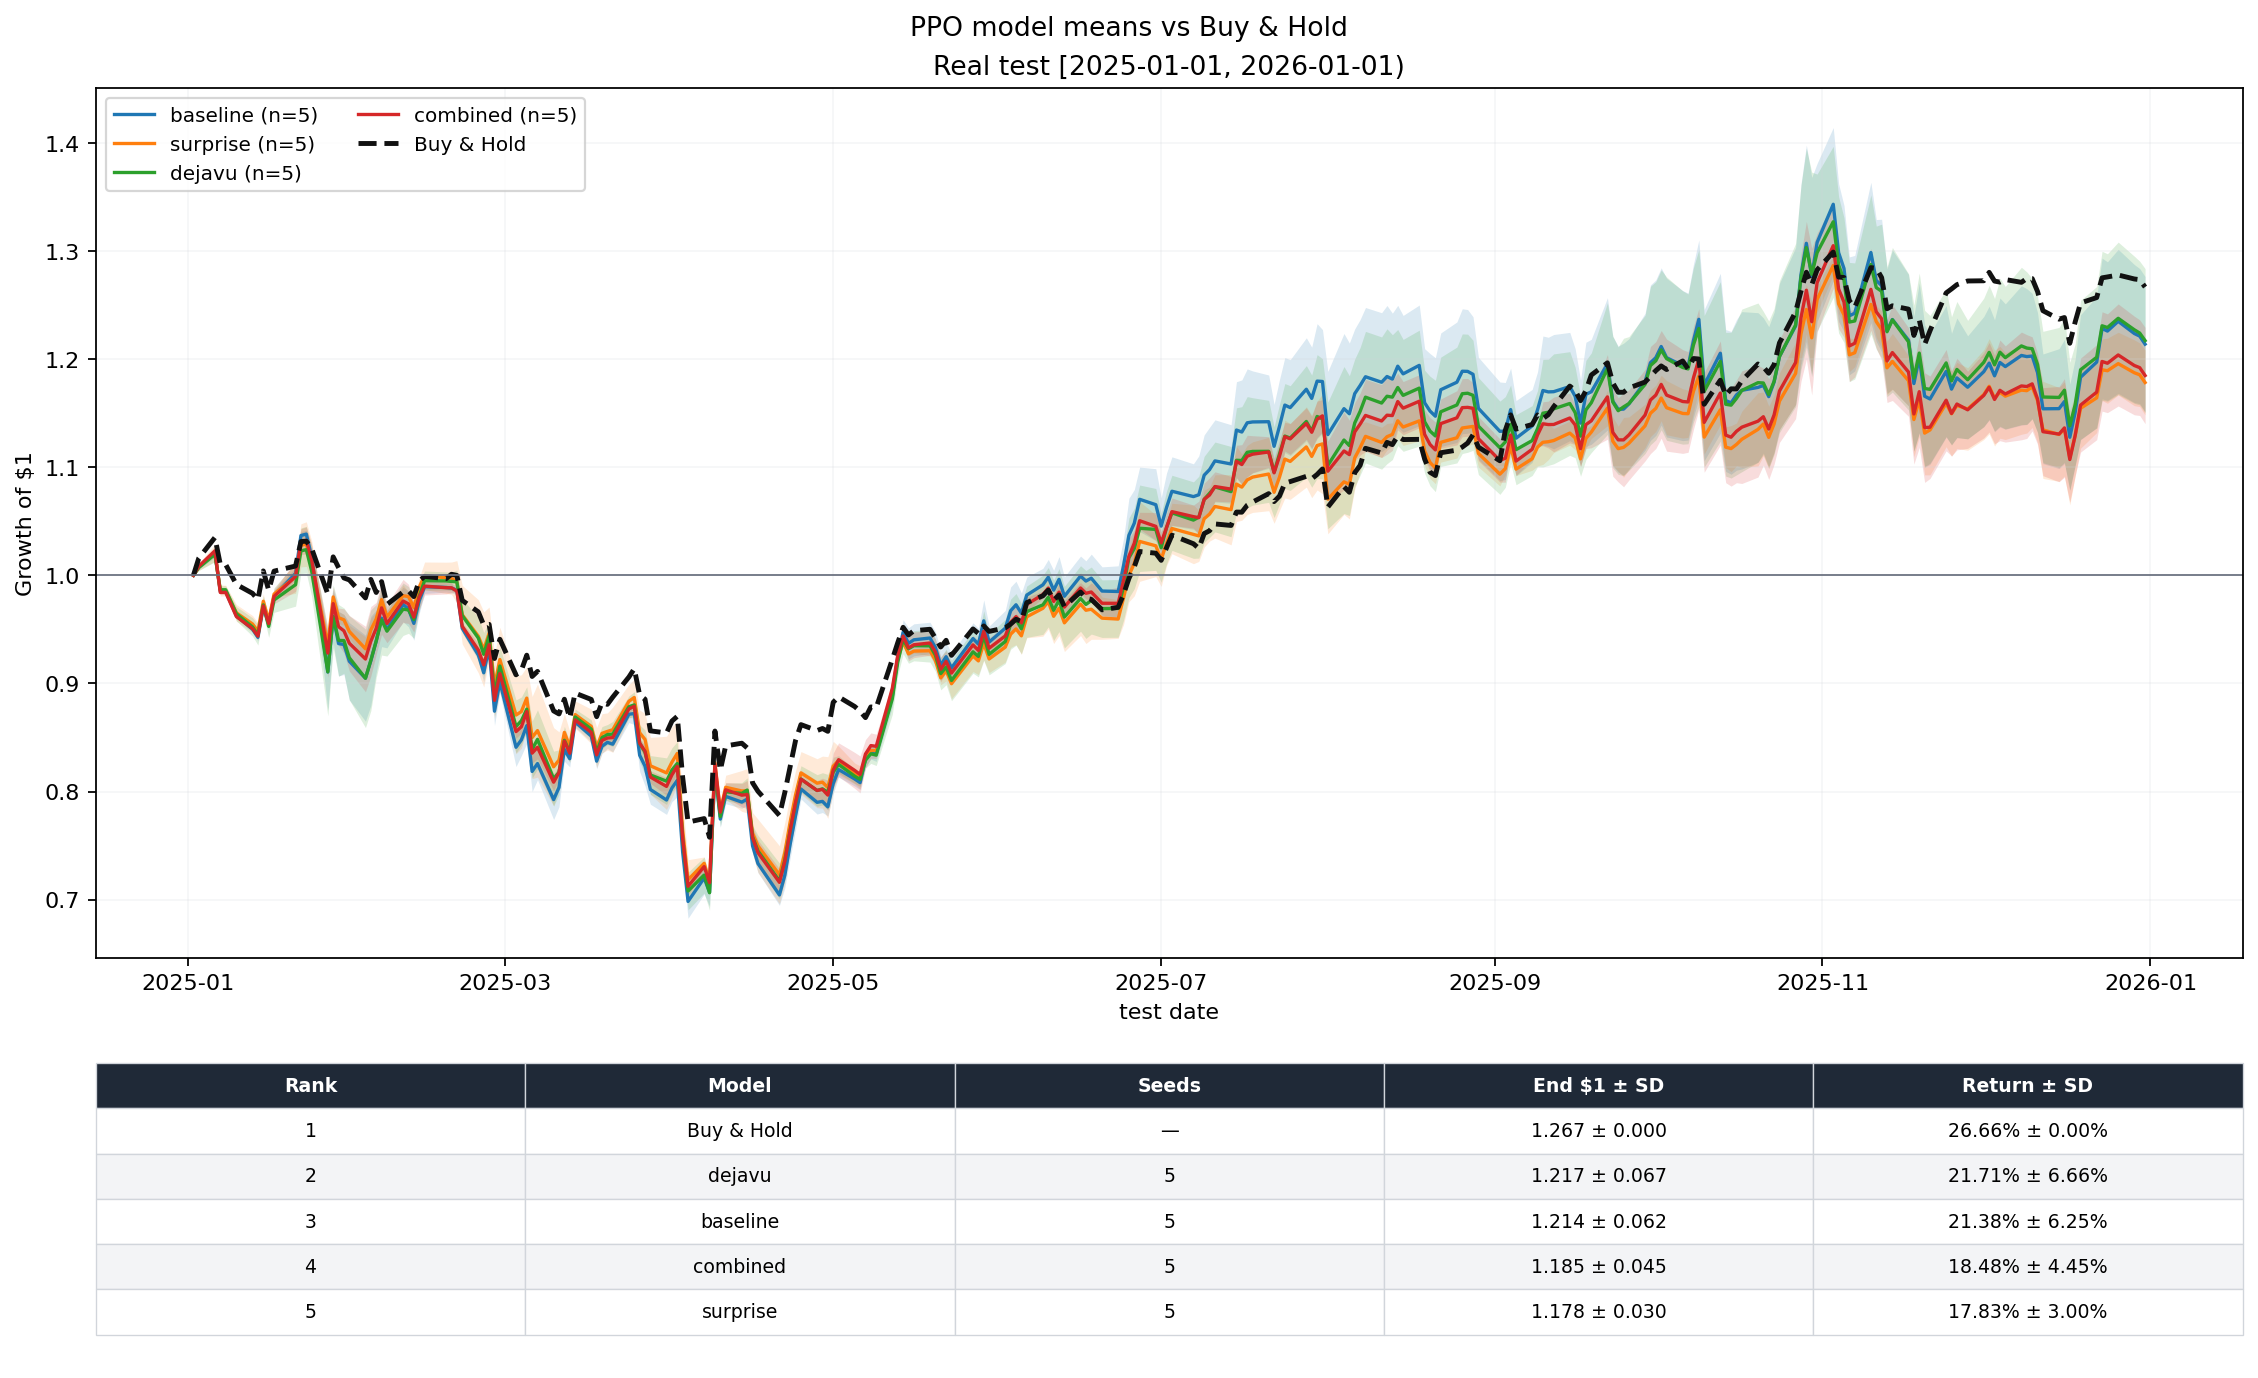

In [17]:
test_figure, test_equity, test_ranking = plot_period_equity_comparison(
    "test",
    period_results["test"],
    buy_and_hold_results["test"],
    f"Real test [{TEST_START}, {TEST_END})",
)
test_path = ARTIFACT_ROOT / "ppo_vs_buy_and_hold_test_equity_curves.png"
test_figure.savefig(test_path, dpi=160, bbox_inches="tight")
plt.close(test_figure)
test_equity.to_csv(ARTIFACT_ROOT / "test_equity_curves.csv", index=False)
test_ranking.to_csv(ARTIFACT_ROOT / "test_equity_ranking.csv", index=False)
NotebookImage(filename=str(test_path))


## 8. Portfolio weights

Actual end-of-day StockTrading portfolio weights are averaged across seeds for
each reward variant. The stacked areas show allocation through the real test
period; the table reports exact average weights.


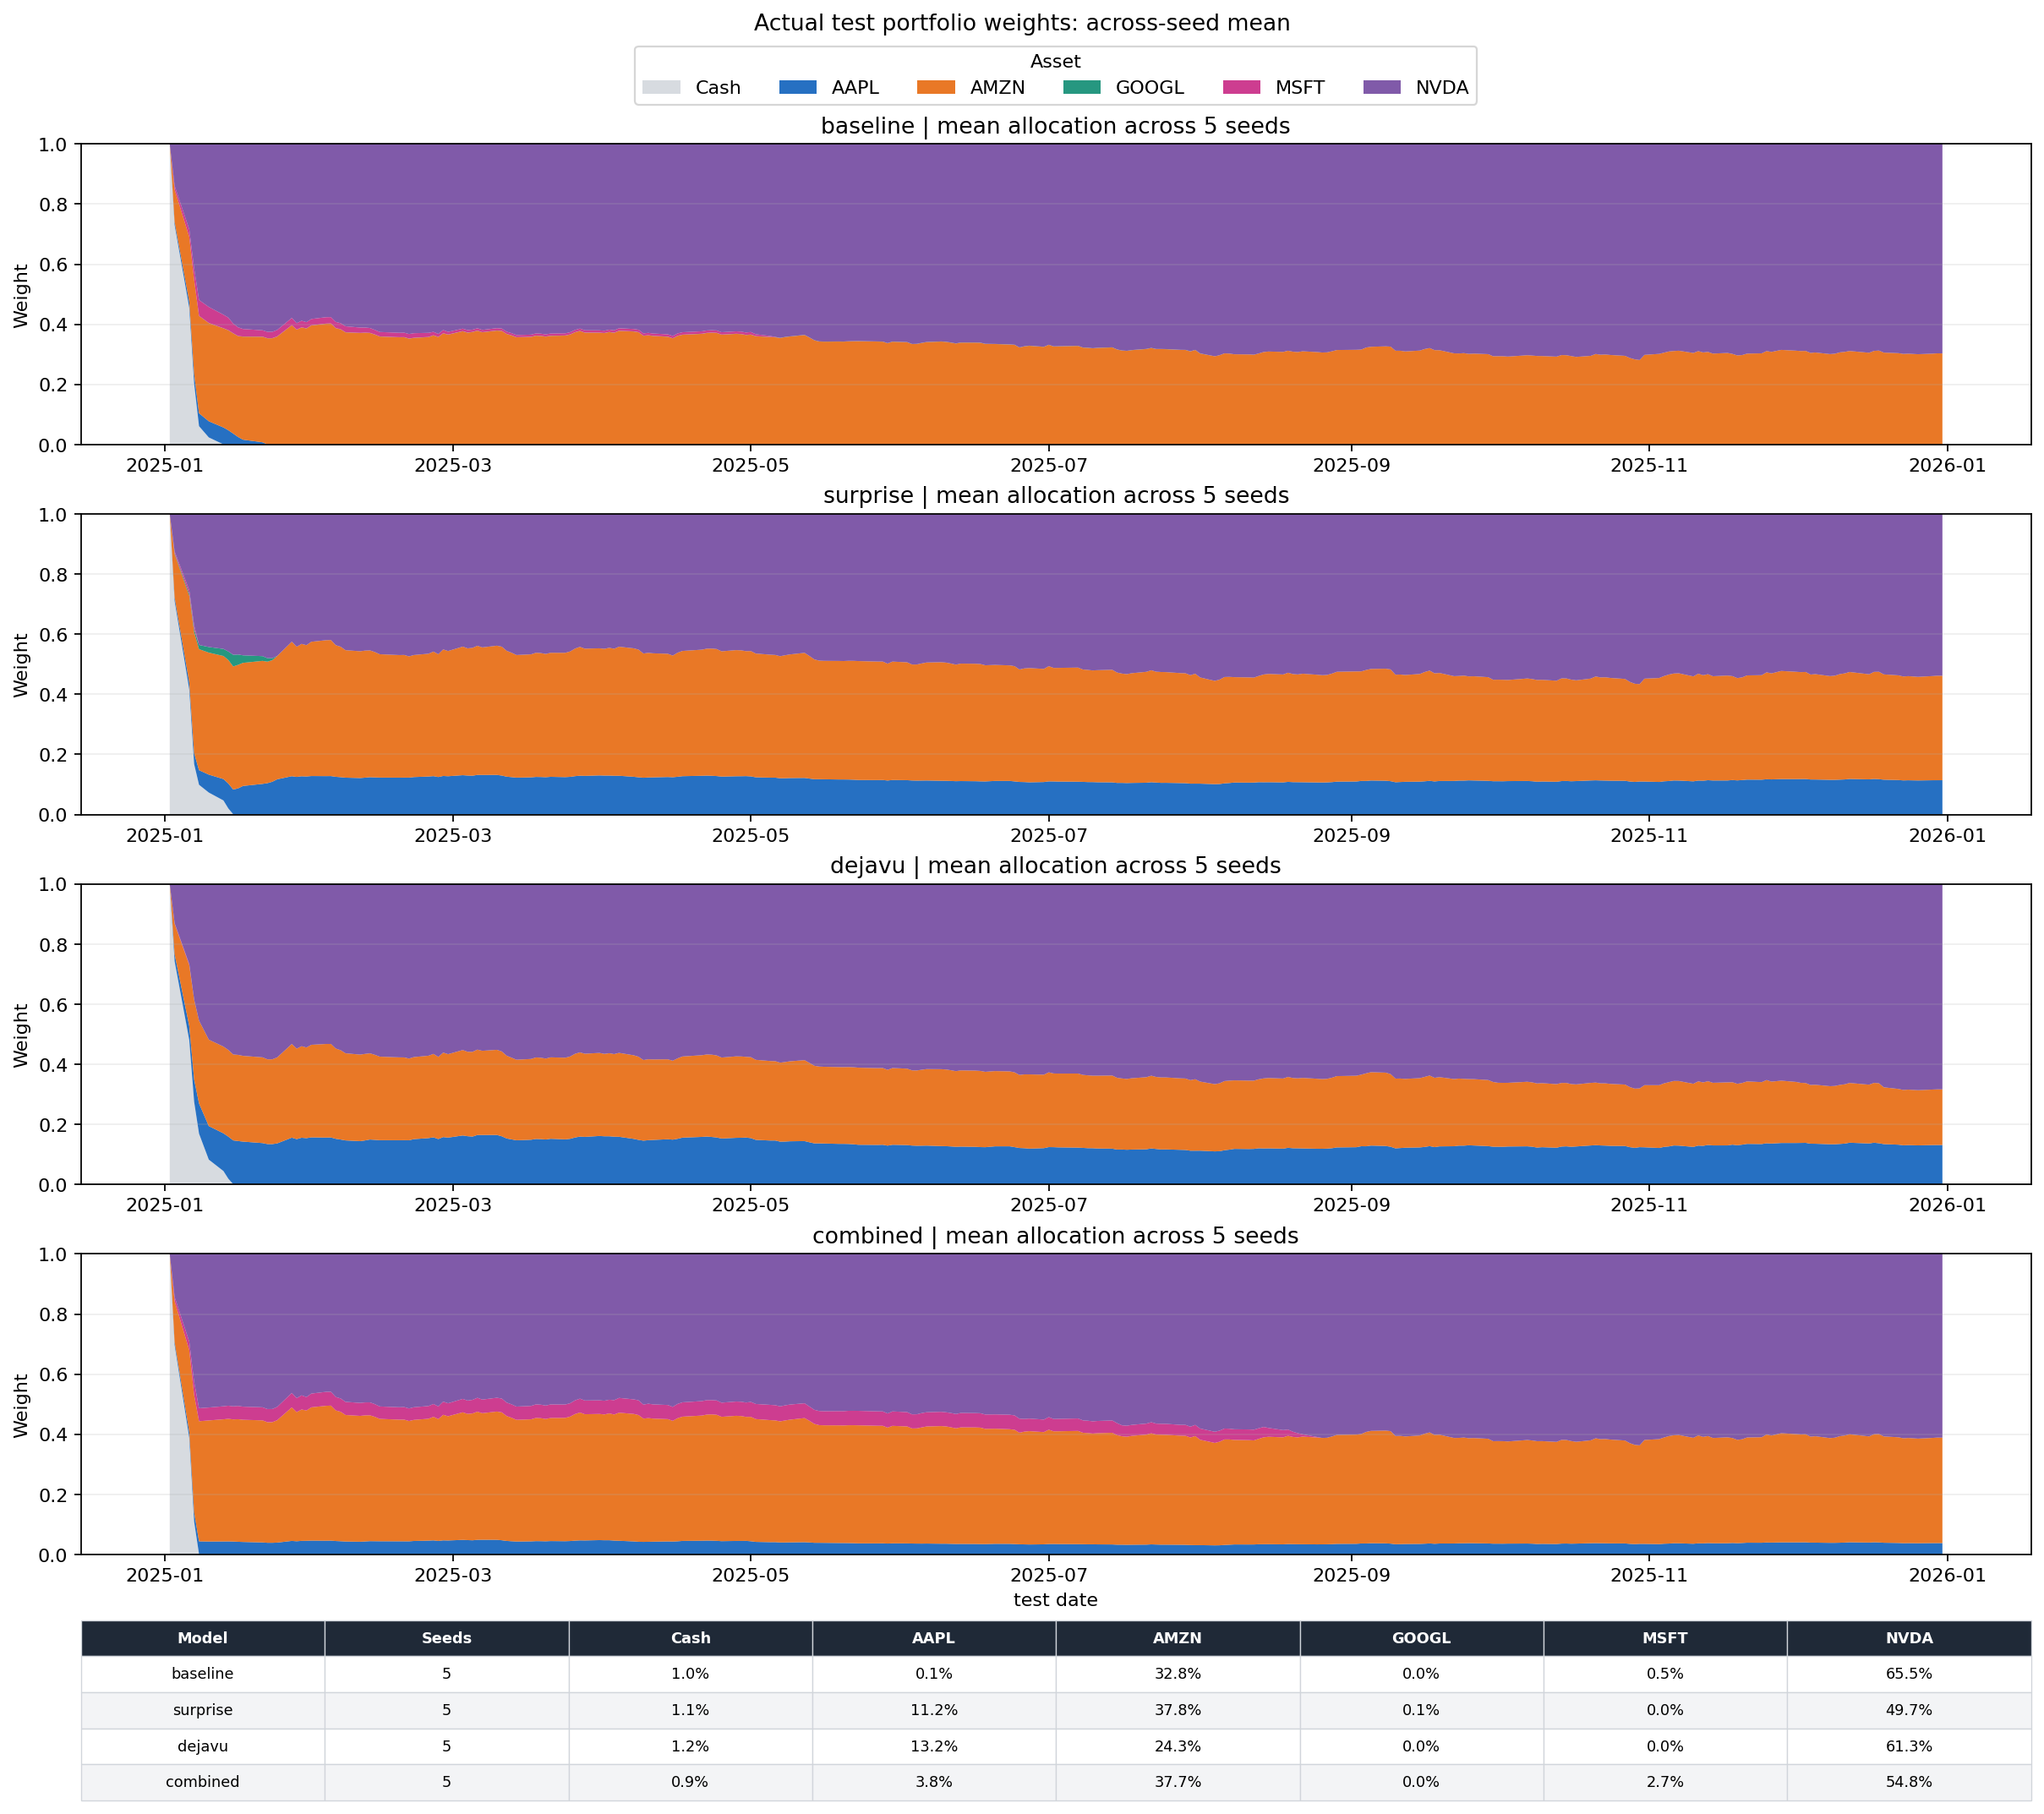

In [18]:
weights_figure, mean_test_weights = plot_test_portfolio_weights(
    period_results["test"]
)
weights_path = ARTIFACT_ROOT / "ppo_real_test_portfolio_weights.png"
weights_figure.savefig(weights_path, dpi=160, bbox_inches="tight")
plt.close(weights_figure)
mean_test_weights.to_csv(
    ARTIFACT_ROOT / "mean_test_portfolio_weights.csv", index=False
)
NotebookImage(filename=str(weights_path))


## 9. Interpretation checklist

- Compare differences with the cross-seed bands, not only point estimates.
- Use validation curves to diagnose overfitting before reading test outcomes.
- Treat intrinsic diagnostics as training-mechanism evidence, not financial P&L.
- Backtest metrics and portfolio plots contain external financial outcomes only.


## Next steps

Run the formal experiment from the repository root. Adjust the CPU thread count for the server; use `FINRL_DEVICE=cuda` only after confirming that configuration is faster on the target machine.

```bash
FINRL_INTRINSIC_RUN_MODE=full \
FINRL_USE_TRAIN_CACHE=1 \
FINRL_DEVICE=cpu \
FINRL_TORCH_NUM_THREADS=8 \
jupyter nbconvert --to notebook --execute --inplace \
  examples/FinRL_StockTrading_IntrinsicReward_Ablation.ipynb \
  --ExecutePreprocessor.timeout=-1
```

The semantic `train_cache/` is versioned so completed runs can be shared across machines. Generated `smoke/` and `full/` reports remain ignored; full cache checkpoints contain replay-pool arrays, so review their size before committing them.


In [19]:
best_row = test_model_summary.loc[
    test_model_summary["sharpe_mean"].idxmax()
]
print(
    "Highest mean PPO Sharpe across seeds:",
    best_row["variant"],
    f"n={int(best_row['seed_count'])}",
    f"Sharpe={best_row['sharpe_mean']:.3f} ± {best_row['sharpe_std']:.3f}",
)
print("Buy & Hold test Sharpe:", f"{test_buy_and_hold['sharpe']:.3f}")
print("Training cache hits:", f"{int(run_table['cache_hit'].sum())}/{len(run_table)}")
print("Treat differences smaller than cross-seed variability cautiously.")


Highest mean PPO Sharpe across seeds: dejavu n=5 Sharpe=0.700 ± 0.123
Buy & Hold test Sharpe: 1.011
Training cache hits: 12/20
Treat differences smaller than cross-seed variability cautiously.
